<a href="https://colab.research.google.com/github/jmontseny/espec_ADD/blob/main/Sprint8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Contexto general

La empresa ha realizado una encuesta interna a todos sus empleados con el objetivo de revisar su política salarial, analizar la movilidad de la plantilla y estudiar cómo factores personales y geográficos pueden influir en futuras decisiones de Recursos Humanos.

Sin embargo, antes de tomar cualquier decisión, el departamento de Data Analytics debe validar que la información recopilada sea fiable y construir un dataset consistente que pueda utilizarse posteriormente para reporting, visualización y simulaciones salariales.

Nuestro trabajo consiste en actuar como analistas de datos del departamento de RRHH.

# 1. Auditoría inicial del dataset
## Contexto de negocio

RRHH nos entrega un fichero procedente de una encuesta realizada a empleados.

Como ocurre habitualmente, nadie garantiza que los datos sean correctos.

Antes de empezar cualquier análisis debemos auditar el dataset para conocer su estado.

No podemos permitir que decisiones de negocio se tomen sobre información desconocida.

## Plan de ejecución

1.   Conocer el tamaño del dataset.
2.   Identificar el tipo de cada variable.
3.   Revisar algunos registros manualmente.
4.   Buscar duplicados.
5.   Detectar posibles problemas evidentes.
6.   Elaborar un diagnóstico inicial de calidad.

In [2]:
# Creamos el DataFrame y vemos las primeras filas

df = pd.read_excel("/content/drive/MyDrive/sprint8_complex.xlsx")
df.head(5)

,Dades de l'enquesta de treballadors 2025,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Generades aleatòriament per seguretat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
3,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
4,1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7


Vemos las primeras filas del DataFrame y nos damos cuenta de que las 3 primeras filas contienen valores NaN a excepción de "Dades de l'enquesta de treballadors 2025" y "Generades aleatòriament per seguretat"

In [3]:
print(f'El DataFrame tiene {df.shape[0]} filas y {df.shape[1]} columnas')

El DataFrame tiene 1010 filas y 20 columnas


In [4]:
# Para ver qué tipo de datos hay en cada columna, usamos .info()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 20 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Dades de l'enquesta de treballadors 2025  1008 non-null   object
 1   Unnamed: 1                                1007 non-null   object
 2   Unnamed: 2                                1007 non-null   object
 3   Unnamed: 3                                1007 non-null   object
 4   Unnamed: 4                                1007 non-null   object
 5   Unnamed: 5                                1007 non-null   object
 6   Unnamed: 6                                1007 non-null   object
 7   Unnamed: 7                                1007 non-null   object
 8   Unnamed: 8                                1007 non-null   object
 9   Unnamed: 9                                967 non-null    object
 10  Unnamed: 10                               1007 n

In [5]:
# Buscamos cuántos duplicados exactos hay

print(df.duplicated().sum())

0


In [6]:
# Presentamos una muestra representativa del DataFrame

df.sample(5)

,Dades de l'enquesta de treballadors 2025,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
42,39,Guillem,Vila,92874006W,Espanya,Murcia,0.0,99.0,3000.0,H,dos mil,NaN,True,Grup A,Senior analyst,0.0,NaN,NaN,NaN,NaN
216,213,Oriol,DÃ­az Romero,10968781V,Espanya,Tarragona,26.0,4.0,1996.0,F,935 â‚¬,NaN,True,Grup A,Administratiu,NaN,True,1000000,25.0,17.1
45,42,Laia,Puig,57287718F,Espanya,Girona,20.0,4.0,1976.0,D,1438â‚¬,NaN,True,Grup A,Senior analyst,0.0,NaN,NaN,NaN,12.9
132,129,Jordi,Serra GarcÃ­a,44795538M,Espanya,Madrid,17.0,9.0,1980.0,Dona,1324 euros,True,NaN,Grup B,Administratiu,4.0,True,19232.0,6.7,18.4
922,919,Nil,HernÃ¡ndez,60855083M,Espanya,Sevilla,24.0,8.0,1988.0,H,"1,331 â‚¬",NaN,True,Grup B,TÃ¨cnic IT,0.0,NaN,NaN,NaN,17.6


Analizando el DataFrame sin manipularlo de ninguna manera, vemos que el DataFrame tiene 1010 filas y 20 columnas, todas las columnas son de tipo object, no parece haber valores duplicados, pero los valores no resultan coherentes a primera vista, ya que no hay nombres de columnas, y las 2 primeras filas son todo valores NaN.

A partir de la 3a fila vemos lo que serían los nombres de las columnas, y a partir de entonces los valores, por lo que lo primero que debemos hacer es limpiar ésto para poder tener una visión más precisa de cómo está estructurado el DataFrame.

También vemos que todas las columnas son del tipo Object, lo cuál es estadísticamente anómalo, y seguramente se deba al hecho de que los nombres de las columnas no están bien alineados.
Otro pequeño detalle que vemos, es que la segunda fila de la primera columna vemos el valor:
"Generades aleatòriament per seguretat"

Como conclusiones hasta aquí, el DataFrame presenta varios problemas e inconsistencias.


In [7]:
df = pd.read_excel("/content/drive/MyDrive/sprint8_complex.xlsx", skiprows=3)
df.head(5)

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1


Aplicando skiprows=3 el DataFrame ya parece algo más saneado y coherente.

In [8]:
# Mostramos cuantas filas y columnas tiene el DataFrame

print(f'El DataFrame tiene {df.shape[0]} filas y {df.shape[1]} columnas')

El DataFrame tiene 1007 filas y 20 columnas


In [9]:
# Mostramos una muestra representativa del DataFrame de 5 personas

df.sample(5)

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
717,717,NÃºria,Casals,91184381T,Espanya,Madrid,24.0,11.0,1961.0,H,1000â‚¬,NaN,True,Grup A,Data Analyst,NaN,False,NaN,NaN,13.6
410,410,Gabriele,Lombardi,14930347Y,ItÃ lia,Firenze,8.0,1.0,2000.0,NC,1432â‚¬,True,NaN,Grup B,Data Analyst,3.0,NaN,NaN,NaN,10.5
429,429,LucÃ­a,HernÃ¡ndez,61268618C,Espanya,Bilbao,24.0,2.0,1995.0,D,"2,290 â‚¬",NaN,True,Grup B,Cap de projecte,0.0,True,65950.0,NaN,15.0
60,60,NÃºria,Navarro,47969333N,Espanya,Girona,30.0,6.0,1981.0,H,"2,125 â‚¬",NaN,NaN,Grup B,TÃ¨cnic IT,NaN,True,NaN,25.0,NaN
744,744,Nil,MartÃ­nez FernÃ¡ndez,81696670A,Espanya,Bilbao,16.0,7.0,1964.0,H,1280â‚¬,NaN,True,Grup A,Data Analyst,2.0,True,99431.0,25.0,NaN


In [10]:
# Buscamos más información sobre el DataFrame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  1007 non-null   int64  
 1   Nom                         1006 non-null   object 
 2   Cognoms                     1006 non-null   object 
 3   DNI                         1006 non-null   object 
 4   País d'origen               1006 non-null   object 
 5   Ciutat                      1006 non-null   object 
 6   Dia de Naixement            1006 non-null   float64
 7   Mes de Naixement            1006 non-null   float64
 8   Any de Naixement            1006 non-null   float64
 9   Gènere                      966 non-null    object 
 10  Salari mensual              1006 non-null   object 
 11  Fills                       419 non-null    object 
 12  No Fills                    585 non-null    object 
 13  Grup Professional           1005 

In [11]:
df.describe()

,Unnamed: 0,Dia de Naixement,Mes de Naixement,Any de Naixement,Nombre_fills,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
count,1007.000000,1006.000000,1006.000000,1006.000000,709.000000,315.000000,261.000000,936.000000
mean,503.000000,15.027833,8.556660,2002.229622,1.203103,55951.050794,11.024521,15.379167
std,290.840162,10.327436,14.298532,143.118077,1.389404,62095.437005,8.775557,7.276425
min,0.000000,-99.000000,0.000000,1940.000000,0.000000,-50.000000,0.500000,-10.000000
25%,251.500000,7.000000,3.250000,1969.000000,0.000000,22632.000000,4.700000,12.800000
50%,503.000000,15.000000,6.000000,1982.000000,1.000000,56135.000000,9.800000,15.500000
75%,754.500000,24.000000,10.000000,1995.000000,2.000000,80000.000000,13.600000,18.300000
max,1006.000000,32.000000,99.000000,3000.000000,5.000000,1000000.000000,25.000000,42.000000


Por los tipos devueltos, vemos que hay algunos problemas e incoherencias:

También tendremos que aplicar un encoding que sea coherente con el idioma para limpiar valores como CÃ rrec o LÃ³pez. Las columnas Dia de Naixement, Mes de Naixement y Any de Naixement son floats pero tendría más sentido que fueran int.

También tendría más sentido agrupar esa información en una sola columna, en cuyo caso tendría más sentido un formato date para poder hacer operaciones.

Por otro lado, salari mensual nos aparece como object, cuando lo más lógico es que fuera un float.

Nombre_fills aparece como float pero tendría más sentido un int. Habrá que analizar en mayor profundidad la distribución del resto de variables pero estas son algunas de las primeras conclusiones que podemos sacar.

También cambiaremos algunos nombres de las columnas para que no tengan espacios en blanco y cambiarlos por "_". Ésto lo haremos principalmente para nuestra comodidad y poder trabajar más eficientemente.

Finalmente, la columna Unnamed: 0 la eliminaremos ya que no aporta ningún valor. El propio DataFrame explica que es una columna con datos "Generades aleatòriament per seguretat"

In [12]:
# Iteramos por las culumnas para saber cuántas hay de cada tipo

column_types = [df[c].dtype for c in df.columns]
column_types = set(column_types)

for type in column_types:
    print(f'Columnas de tipo {type}: {df.select_dtypes(include=[type]).shape[1]}')

Columnas de tipo object: 12
Columnas de tipo float64: 7
Columnas de tipo int64: 1


In [13]:
# Buscamos cuántos duplicados hay en el DataFrame

df.duplicated().sum()

np.int64(0)

A priori parece no haber duplicados exactos en el DataFrame.

In [14]:
# Iteramos por todas las columnas para ver valores duplicados por columna

for columna in df.columns:
    print(f'Variable: {columna}, con {df.duplicated(subset=columna).sum()} valores duplicados')

Variable: Unnamed: 0, con 0 valores duplicados
Variable: Nom, con 903 valores duplicados
Variable: Cognoms, con 538 valores duplicados
Variable: DNI, con 15 valores duplicados
Variable: País d'origen, con 1000 valores duplicados
Variable: Ciutat, con 961 valores duplicados
Variable: Dia de Naixement, con 971 valores duplicados
Variable: Mes de Naixement, con 991 valores duplicados
Variable: Any de Naixement, con 955 valores duplicados
Variable: Gènere, con 997 valores duplicados
Variable: Salari mensual, con 151 valores duplicados
Variable: Fills, con 1005 valores duplicados
Variable: No Fills, con 1004 valores duplicados
Variable: Grup Professional, con 1001 valores duplicados
Variable: CÃ rrec, con 992 valores duplicados
Variable: Nombre_fills, con 1000 valores duplicados
Variable: Te_cotxe, con 1004 valores duplicados
Variable: Km_anuals, con 836 valores duplicados
Variable: Consum_mitja_L_100km, con 922 valores duplicados
Variable: Temperatura_mitjana_ciutat, con 820 valores duplic

En la práctica no tiene mucho sentido identificar valores duplicados para cada columna, pero nos da una idea de dónde encontraremos
valores duplicados que tendremos que limpiar en aquellas columnas objetivo, como podrían ser DNI para este caso.

También ver que la columna "Unnamed: 0" no tiene ningún valor duplicado también nos confirma que es un identificador aleatorio y podemos deshacernos de él, ya que no aporta ningún valor.

Tras una primera valoración simplemente aplicando skiprows al DataFrame vemos que vamos a tener que renombrar columnas para mayor comodidad a la hora de trabajar,
estandarizar el formato de palabras "latin1" o "utf-8", estandarizar valores de columnas numéricas (Salari mensual al ser de tipo Object es muy posible que tenga valores alfanuméricos o símbolos de divisa).

También tendremos que analizar en detalle los valores de columnas que puedan ser booleanas, como Fills y No Fills, y ver si el resultado es coherente con Nombre_fills (if Fills == True --> Nombre_fills > 0 // if No Fills == True --> Nombre_fills = 0). Una vez contrastada esa coherencia podríamos eliminar alguna de estas 3 columnas, ya que por ejemplo con Nombre_fills podemos inferir el resultado de Fills y No Fills y por lo tanto es redundante.

Luego tendremos que limpiar valores de todas las columnas, y gestionar los valores duplicados, así como imputar valores nulos.

################################################################

# 2. Validación de calidad de datos
## Contexto de negocio

Una vez conocemos el estado del dataset, debemos decidir qué registros son suficientemente fiables para formar parte del análisis.

En una empresa real no todos los errores se corrigen; algunos registros simplemente dejan de ser utilizables.

## Plan de ejecución

1.   Corregir problemas de codificación.
2.   Eliminar duplicados exactos.
3.   Verificar que cada empleado tenga un DNI único.
4.   Analizar registros repetidos.
5.   Detectar registros imposibles de recuperar.
6.   Eliminar únicamente la información irrecuperable.

La filosofía es eliminar únicamente aquello que no puede salvarse.

In [15]:
# Renombramos las columnas y las codificamos para poder trabajar mejor con ellas

df = df.rename(columns={"CÃ\xa0rrec": "Càrrec"})

df.columns = df.columns.str.replace(" ", "_").str.capitalize()

df = df.rename(columns={"Dni": "DNI", "País_d'origen": "País_origen"})

In [16]:
# Eliminamos la columna Unnamed:_0

df = df.drop('Unnamed:_0', axis=1)

In [17]:
# Buscamos cantidad de valores nulos por columna

df.isnull().sum()

,0
Nom,1
Cognoms,1
DNI,1
País_origen,1
Ciutat,1
Dia_de_naixement,1
Mes_de_naixement,1
Any_de_naixement,1
Gènere,41
Salari_mensual,1


In [18]:
# Seleccionamos las columnas de tipo objeto

df.select_dtypes(include="object").columns

Index(['Nom', 'Cognoms', 'DNI', 'País_origen', 'Ciutat', 'Gènere',
       'Salari_mensual', 'Fills', 'No_fills', 'Grup_professional', 'Càrrec',
       'Te_cotxe'],
      dtype='object')

In [19]:
# Definimos las columnas que queremos decodificar

columnas_texto = [
    'Nom', 'Cognoms', "País_origen", 'Ciutat', 'Gènere',
    'Salari_mensual', 'Grup_professional', 'Càrrec'
    ]

for columna in columnas_texto:
    df[columna] = (
        df[columna]
        .str.encode("latin1", errors="ignore")
        .str.decode("utf-8", errors="ignore")
    )

In [20]:
# Buscamos valores duplicados

df.duplicated().sum()

np.int64(4)

In [21]:
# Mostramos los registros duplicados

df[df.duplicated(keep=False)]

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
36,Ida,Karlsen Eriksen,55283701C,Noruega,Oslo,2.0,9.0,1992.0,D,"1,614",True,NaN,Grup B,Analista,3.0,NaN,NaN,NaN,10.6
40,Ida,Karlsen Eriksen,55283701C,Noruega,Oslo,2.0,9.0,1992.0,D,"1,614",True,NaN,Grup B,Analista,3.0,NaN,NaN,NaN,10.6
372,Alba,Muñoz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
730,Claudia,Gil Ferrer,55297384F,Espanya,València,1.0,11.0,1981.0,H,1.789,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
757,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1002,Alba,Muñoz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
1003,Claudia,Gil Ferrer,55297384F,Espanya,València,1.0,11.0,1981.0,H,1.789,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9


In [22]:
# Borramos los registros duplicados

pre_drop_duplicates = df.shape[0]
print(f'Cantidad de registros antes de eliminar valores duplicados: {df.shape[0]}')
df.drop_duplicates(inplace=True)
post_drop_duplicates = df.shape[0]
print(f'Cantidad de registros después de eliminar valores duplicados: {df.shape[0]}')
print(f'Cantidad de registros eliminados: {pre_drop_duplicates - post_drop_duplicates}')

Cantidad de registros antes de eliminar valores duplicados: 1007
Cantidad de registros después de eliminar valores duplicados: 1003
Cantidad de registros eliminados: 4


In [23]:
# Buscamos la cantidad de valores duplicados por la variables "DNI"

print(df.duplicated(subset='DNI').sum())

11


In [24]:
# Mostramos los valores duplicados por "DNI" y los odernamos por "DNI"

df[df['DNI'].duplicated(keep=False)].sort_values(by='DNI')

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
250,Laia,Navarro Vila,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,1235 euros,True,True,Grup D,Analista junior,0.0,False,NaN,NaN,10.3
604,Laia,Navarro,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,"1,676",True,False,Grup A,Analista,1.0,True,50.0,NaN,14.2
654,Oriol,Gómez,16618423V,Espanya,Madrid,10.0,1.0,1968.0,Home,1731 euros,True,NaN,Grup B,Data analyst,4.0,NaN,NaN,NaN,NaN
754,Oriol,Gómez,16618423V,Espanya,Barcelona,10.0,1.0,1968.0,Home,2.358,True,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
758,Oriol,Gómez,16618423V,Espanya,Màlaga,10.0,1.0,1968.0,H,1879 euros,True,NaN,Grup B,Data Analyst,4.0,False,NaN,NaN,NaN
759,Oriol,Gómez,16618423V,Espanya,Sevilla,10.0,1.0,1968.0,NaN,"2,000",NaN,NaN,Grup A,Responsable de vendes,5.0,NaN,NaN,NaN,20.7
558,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,"1,176",NaN,True,Grup A,Data Analyst,0.0,False,NaN,NaN,38.0
692,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,1663,NaN,True,Grup C,Cap de projecte,NaN,True,80000.0,10.7,16.9
89,Guillem,Pujol Costa,54013571W,Espanya,A Coruña,17.0,7.0,1983.0,D,1.574,True,NaN,Grup B,Project lead,4.0,False,NaN,NaN,14.6
142,Marta,Ruiz,54013571W,Espanya,Palma,24.0,5.0,1982.0,H,"1,276",True,True,Grup A,Analista,0.0,False,NaN,NaN,15.7


In [25]:
# Iteramos por valores de DNI duplicados y los mostramos agrupados para poder analizarlos mejor

for dni in df['DNI'][df['DNI'].duplicated()].unique():
    display(df[df['DNI'] == dni])

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
25,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,993,NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8
104,Oriol,Vila Casals,90585882A,Espanya,Madrid,30.0,9.0,1964.0,H,1987 euros,NaN,True,Grup B,Responsable de vendes,0.0,False,NaN,NaN,13.5
114,Pol,Serra,90585882A,Espanya,Girona,4.0,12.0,1960.0,H,"1,178",NaN,True,Grup A,Data Analyst,NaN,False,NaN,NaN,16.2
281,Xavier,Vidal,90585882A,Espanya,Alacant,2.0,7.0,1958.0,H,1179 euros,NaN,NaN,Grup A,Tècnic IT,0.0,True,63574.0,6.0,16.8
913,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,Dona,"1,000",NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8
1000,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,"1,073",NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8


,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
89,Guillem,Pujol Costa,54013571W,Espanya,A Coruña,17.0,7.0,1983.0,D,1.574,True,NaN,Grup B,Project lead,4.0,False,NaN,NaN,14.6
142,Marta,Ruiz,54013571W,Espanya,Palma,24.0,5.0,1982.0,H,"1,276",True,True,Grup A,Analista,0.0,False,NaN,NaN,15.7


,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
250,Laia,Navarro Vila,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,1235 euros,True,True,Grup D,Analista junior,0.0,False,NaN,NaN,10.3
604,Laia,Navarro,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,"1,676",True,False,Grup A,Analista,1.0,True,50.0,NaN,14.2


,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
558,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,"1,176",NaN,True,Grup A,Data Analyst,0.0,False,NaN,NaN,38.0
692,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,1663,NaN,True,Grup C,Cap de projecte,NaN,True,80000.0,10.7,16.9


,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
654,Oriol,Gómez,16618423V,Espanya,Madrid,10.0,1.0,1968.0,Home,1731 euros,True,NaN,Grup B,Data analyst,4.0,NaN,NaN,NaN,NaN
754,Oriol,Gómez,16618423V,Espanya,Barcelona,10.0,1.0,1968.0,Home,2.358,True,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
758,Oriol,Gómez,16618423V,Espanya,Màlaga,10.0,1.0,1968.0,H,1879 euros,True,NaN,Grup B,Data Analyst,4.0,False,NaN,NaN,NaN
759,Oriol,Gómez,16618423V,Espanya,Sevilla,10.0,1.0,1968.0,NaN,"2,000",NaN,NaN,Grup A,Responsable de vendes,5.0,NaN,NaN,NaN,20.7


Analizando cada subconjunto de valores duplicados por DNI, vemos que "15909601K" (Laia Navarro Vila) ha dejado de ser Analista Junior para ser Analista, por lo que mantendremos el último resultado. Al no disponer de información adicional sobre la fecha de actualización de los registros, asumiremos que el último registro corresponde a la versión más reciente del empleado.

Para "49529438G" (Alexia Pérez Díaz) y "16618423V" (Oriol Gómez) asumimos algo similar a la situación de "15909601K" (Laia Navarro Vila), por lo que mantendremos la última información por estar más actualizada. Sin embargo, si miramos en detalle a Oriol vemos que perdemos algunos datos si nos quedamos sólo con el último, por lo que tendremos que actualizar algunos valores antes de eliminar el resto de registros.

Para el caso de "54013571W" (Guillem Pujol Costa / Marta Ruiz), es imposible saber cuál de los dos registros es el verdadero sin hablar directamente con el equipo de RRHH, por lo que para este ejercicio eliminaremos ambos registros para no contaminar el DataFrame.

Finalmente, el caso del empleado "90585882A", parece haber 6 registros diferentes, pero en 3 de ellos se mantiene un mismo nombre, Sara Serra. Lo ideal en este caso sería confirmarlo con RRHH, pero para este caso, y viendo cómo están distribuídos los datos, es bastante probable que el último registro sea el más actualizado, como ya vimos en otros casos.


Para ser eficientes, podemos eliminar todos los registros cuyo DNI sean "54013571W", tratar los datos de "16618423V" (Oriol Gómez), y finalmente eliminar todos los demás duplicados quedándonos solo con el último registro.

In [26]:
# Definimos los dnis_invalidos y los eliminamos

dnis_invalidos = ["54013571W"]

indices_a_eliminar = df[df["DNI"].isin(dnis_invalidos)].index

df = df.drop(indices_a_eliminar)

In [27]:
# Confirmamos que se han eliminado los registros

df[(df['DNI'] == "54013571W")]

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat


In [28]:
# Definimos al candidato Oriol

oriol = df[df["DNI"] == "16618423V"]
oriol

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
654,Oriol,Gómez,16618423V,Espanya,Madrid,10.0,1.0,1968.0,Home,1731 euros,True,NaN,Grup B,Data analyst,4.0,NaN,NaN,NaN,NaN
754,Oriol,Gómez,16618423V,Espanya,Barcelona,10.0,1.0,1968.0,Home,2.358,True,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
758,Oriol,Gómez,16618423V,Espanya,Màlaga,10.0,1.0,1968.0,H,1879 euros,True,NaN,Grup B,Data Analyst,4.0,False,NaN,NaN,NaN
759,Oriol,Gómez,16618423V,Espanya,Sevilla,10.0,1.0,1968.0,NaN,"2,000",NaN,NaN,Grup A,Responsable de vendes,5.0,NaN,NaN,NaN,20.7


In [29]:
# Guardamos los valores del último registro del empleado Oriol

ultimo_oriol = oriol.iloc[-1].copy()
ultimo_oriol

,759
Nom,Oriol
Cognoms,Gómez
DNI,16618423V
País_origen,Espanya
Ciutat,Sevilla
Dia_de_naixement,10.0
Mes_de_naixement,1.0
Any_de_naixement,1968.0
Gènere,NaN
Salari_mensual,"2,000"


In [30]:
# Iteramos por las columnas del DataFrame, y si el valor del último registro de Oriol es nulo, lo reemplazamos por el valor del penúltimo registro

for columna in df.columns:

    if pd.isna(ultimo_oriol[columna]):

        ultimo_oriol[columna] = oriol.iloc[-2][columna]

# Para nuestro caso, con este código ya nos serviría para extraer la información que necesitamos antes de eliminar los valores duplicados.
# Todavía nos quedarán valores NaN, pero podemos inferirlos de otras columnas, como Fills, o imputarlos más adelante.


In [31]:
print(f'Cantidad de registros antes de eliminar valores de DNI duplicados: {df.shape[0]}')

Cantidad de registros antes de eliminar valores de DNI duplicados: 1001


In [32]:
# Eliminamos el resto de registros duplicados por "DNI" y nos quedamos con el último registro

df = df.drop_duplicates(subset='DNI', keep='last')

In [33]:
print(f'Cantidad de registros después de eliminar valores de DNI duplicados: {df.shape[0]}')

Cantidad de registros después de eliminar valores de DNI duplicados: 991


In [34]:
# Verificamos que no quedan valores duplicados por DNI

print(df.duplicated(subset='DNI').sum())

df['DNI'][df['DNI'].duplicated()]

0


,DNI


Identificamos campos clave que no deberían contener valores nulos

Teniendo en cuenta las preguntas que el equipo quiere responder, es imprescindible que limpiemos el DataFrame de valores nulos en las columnas de "Gènere", "Salari_mensual", y "País_origen". Más adelante también tendremos que tener listos "Grup_Professional", "Edat", "Fills", "No_Fills", "Nombre_fills" y "Ciutat".

# 3. Limpieza y preparación
## Contexto de negocio

Ahora que sabemos qué registros son válidos, debemos convertir el dataset en un conjunto de datos coherente.

Muchas variables contienen información redundante, formatos diferentes o relaciones inconsistentes.

Nuestro objetivo es que cada variable represente correctamente un único concepto.

## Plan de ejecución

1.   Normalizar categorías.
1.   Revisar coherencia entre hijos y número de hijos.
1.   Revisar coherencia entre coche, kilometraje y consumo.
1.   Completar temperatura.
1.   Completar salarios utilizando criterios analíticos.
1.   Convertir fechas.
1.   Unificar variables redundantes.
1.   Dejar el dataset listo para análisis.

In [35]:
# Buscamos cantidad de registros nulos por cada columna

df.isnull().sum()

,0
Nom,1
Cognoms,1
DNI,1
País_origen,1
Ciutat,1
Dia_de_naixement,1
Mes_de_naixement,1
Any_de_naixement,1
Gènere,41
Salari_mensual,1


In [36]:
# Visualizamos el valor nulo en la columna "Nom"

df[df["Nom"].isnull()]

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Al identificar el registro con nombre nulo, vemos que todos los valores de las columnas son nulos, por lo que eliminaremos el registro por completo.

In [37]:
# Borramos el registro

df.dropna(subset=['Nom'], inplace = True)

In [38]:
# Vemos que ésto nos ha ayudado a limpiar el resto de columnas que solo tenían un registro nulo

df.isnull().sum()

,0
Nom,0
Cognoms,0
DNI,0
País_origen,0
Ciutat,0
Dia_de_naixement,0
Mes_de_naixement,0
Any_de_naixement,0
Gènere,40
Salari_mensual,0


In [39]:
# Analizamos registros nulos en la columna "Gènere"

df[df["Gènere"].isnull()].head()

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
61,Xavier,Muñoz Roca,21370793D,Espanya,València,20.0,3.0,1983.0,NaN,3016,NaN,True,Grup D,Tècnic IT,0.0,False,NaN,NaN,15.1
91,Alexia,Gil,89968863W,Espanya,Palma,25.0,11.0,1973.0,NaN,2.257,True,NaN,Grup C,Responsable de vendes,1.0,True,80000.0,11.5,17.7
102,Noa,Ruiz Pérez,18113477L,Espanya,Murcia,12.0,8.0,1990.0,NaN,"2,627",True,NaN,Grup D,Responsable de vendes,1.0,False,NaN,NaN,22.2
109,Katharina,Braun Fischer,93240786N,Alemanya,Leipzig,11.0,7.0,1958.0,NaN,mil vuit-cents,True,NaN,Grup B,Administratiu,1.0,True,76180.0,NaN,9.1
126,Lucas,Petit,17324144F,França,Paris,21.0,5.0,1983.0,NaN,2227,True,NaN,Grup C,Responsable de vendes,1.0,False,NaN,NaN,12.6


In [40]:
# Vemos la cantidad de registros por valores únicos en la variable "Gènere"

df["Gènere"].value_counts(dropna=False)

,count
Gènere,
D,319
H,274
Dona,118
F,107
Home,50
NaN,40
M,34
A,24
NC,23


In [41]:
df[df['Gènere'] == "??"]

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
1006,???,###,XXXX,Narnia,Desconeguda,-99.0,99.0,3000.0,??,molts,NaN,NaN,Z,???,NaN,NaN,NaN,NaN,NaN


Consideramos el registro con el valor en Gènere "??" un error de calidad del dato y eliminamos el registro ya que tras analizarlo ninguna de las variables parece real.

In [42]:
# Eliminamos el registro

df = df[df["Gènere"] != "??"]

Para poder trabajar con la variable "Gènere", tendremos que normalizar los valores de la columna, unificando las distintas representaciones de Hombre (Home) y Mujer (Dona). Los valores A (posiblemente "Altre"), NC (seguramente "No Contesta") y los registros nulos los transformaremos en No especificado, ya que no existe información suficiente para inferir el género de forma fiable.

In [43]:
# Creamos un mapa de géneros para normalizar y lo aplicamos

mapa_genero = {
    "D": "Dona",
    "Dona": "Dona",
    "F": "Dona",

    "H": "Home",
    "Home": "Home",
    "M": "Home",

    "A": "No especificado",
    "NC": "No especificado"
}

df["Gènere"] = df["Gènere"].replace(mapa_genero)

In [44]:
# Rellenamos los valores nulos con "No especificado"

df["Gènere"] = df["Gènere"].fillna("No especificado")

In [45]:
# Analizamos una muestra de hombres

df[["Nom", "Gènere"]][df["Gènere"] == "Home"].sample(20)

,Nom,Gènere
821,Xavier,Home
7,Carmen,Home
682,Carmen,Home
813,Riccardo,Home
382,Marina,Home
582,Marc,Home
992,Sara,Home
232,Marta,Home
731,Irene,Home
27,Chloé,Home


In [46]:
# Analizamos una muestra de mujeres

df[["Nom", "Gènere"]][df["Gènere"] == "Dona"].sample(20)

,Nom,Gènere
809,Núria,Dona
749,Hugo,Dona
706,Clara,Dona
344,Sara,Dona
464,Sofie,Dona
148,Alba,Dona
235,Alejandro,Dona
748,Pau,Dona
716,Lucía,Dona
857,Núria,Dona


Analizando una muestra del DataFrame por "Gènere" vemos que puede haber posibles incongruencias. Encontramos bastantes nombres tradicionalmente másculinos/femeninos que no encajan con el "Gènere". No podemos asumir que lo han introducido mal y tampoco tenemos suficiente evidencia para imputar los datos, por lo que los dejamos como están.

In [47]:
# Vemos la distribución tras limpiar la variable

df["Gènere"].value_counts(dropna=False)

,count
Gènere,
Dona,544
Home,358
No especificado,87


In [48]:
print(f'Cantidad de registros después de limpiar la variable "Gènere": {df.shape[0]}')

Cantidad de registros después de limpiar la variable "Gènere": 989


Teniendo en cuenta las preguntas que el equipo quiere responder, es imprescindible que limpiemos el DataFrame de valores nulos en las columnas de "Salari_mensual",
"Gènere", y "País_origen". Más adelante también tendremos que tener lista "Grup_Professional", "Edat", "Fills", "No_Fills", "Nombre_fills" y "Ciutat".

In [49]:
# Analizamos la distribución de "Salari_mensual"

df["Salari_mensual"].value_counts(dropna=False)

,count
Salari_mensual,
n/d,14
mil vuit-cents,9
dos mil,7
tres mil,6
"1,644",4
...,...
897,1
"1,296",1
"1,591",1


In [50]:
# Existen valores de salario escritos en formato no numérico. Para identificarlos:

df["Salari_mensual"].str.contains(r"[aeiou]", regex=True).value_counts()

,count
Salari_mensual,
False,845
True,144


Comparando con el value_counts() que hicimos antes, vemos que 22 valores contienen alguna vocal, que justo encaja con:

mil vuit-cents:     9

dos mil:            7

tres mil:           6

El resto de valores hasta 144 son valores que seguramente contengan la palabra "euros" escrita tras el valor numérico, pero tendremos que verificarlo.

In [51]:
# Creamos un diccionario con los valores no numéricos y su equivalente numérico y lo aplicamos

salarios_texto = {
    "mil vuit-cents": "1800",
    "dos mil": "2000",
    "tres mil": "3000",
    "n/d": np.nan
}

df["Salari_mensual"] = df["Salari_mensual"].replace(salarios_texto)

In [52]:
df["Salari_mensual"].value_counts(dropna=False)

,count
Salari_mensual,
NaN,14
1800,9
2000,7
3000,6
"1,644",4
...,...
897,1
"1,296",1
"1,591",1


In [53]:
# Para ver qué registros pueden contener símbolos como por ejemplo los del dollar o el euro

df["Salari_mensual"].str.contains(r"[€$]", regex=True).value_counts()

,count
Salari_mensual,
False,975


In [54]:
# Para ver qué registros pueden contener símbolos como "," o "."

df["Salari_mensual"].str.contains(r"[,.]", regex=True).value_counts()

,count
Salari_mensual,
True,550
False,425


In [55]:
# Analizamos los valores que contienen "," o "."

df[df["Salari_mensual"].str.contains(r"[,.]", regex=True, na=False)]["Salari_mensual"].head(15)

,Salari_mensual
0,"1,469"
1,"2,718"
3,"1,478"
4,"1,284"
5,"2,069"
6,"2,349"
7,"2,855"
8,"1,338"
9,"1,450"
11,"2,419"


In [56]:
# Verificamos que los números con "[,.]" sean todos para separar miles, y no valores decimales

df[df["Salari_mensual"].str.contains(r"[,.]", regex=True, na=False)]["Salari_mensual"].sample(20)

,Salari_mensual
813,"1,319"
576,"1,469"
831,"1,778"
504,"1,015"
242,"2,382"
959,"1,501"
764,"1,209"
392,"3,284"
520,1.081
630,"1,579"


In [57]:
# Reemplazamos ".", ",", y "euros" por espacios en blanco para elimininarlos,
# y eliminamos posibles espacios en blanco en los extremos para acabar de aislar el valor numérico


"""df["Salari_mensual"] = (
    df["Salari_mensual"]
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("euros", "", regex=False)
    .str.strip()
)"""

'df["Salari_mensual"] = (\n    df["Salari_mensual"]\n    .str.replace(".", "", regex=False)\n    .str.replace(",", "", regex=False)\n    .str.replace("euros", "", regex=False)\n    .str.strip()\n)'

In [58]:
# Utilizamos una regex para quedarnos solo con la parte numérica

df["Salari_mensual"] = (
    df["Salari_mensual"]
        .str.replace(r"[^\d]", "", regex=True)
)


In [59]:
# Comprobamos los valores que si se transformaran con to_numeric nos darían error

salarios_invalidos = df.loc[
    pd.to_numeric(df["Salari_mensual"], errors="coerce").isna(),
    "Salari_mensual"
]

print(salarios_invalidos.unique())

[nan]


In [60]:
# Convertimos los valores de Salari_mensual a valores numéricos

df["Salari_mensual"] = pd.to_numeric(
    df["Salari_mensual"],
    errors="coerce"
)

In [61]:
df["Salari_mensual"].value_counts(dropna=False)

,count
Salari_mensual,
NaN,14
1800.0,9
2000.0,8
3000.0,6
1021.0,5
...,...
2179.0,1
1531.0,1
2419.0,1


Hemos conseguido transformar todos los valores a valores numéricos sin crear nuevos NaN

Pasamos a analizar las variables "Fills", "No_fills", y "Nombre_fills", ya que están relacionadas entre sí.

In [62]:
# Posibles datos incongruentes que podemos encontrarnos:

print(f'Cantidad de registros con valor True tanto en "Fills" como en "No_fills": {df[(df["Fills"] == True) & (df["No_fills"] == True)].shape[0]}')

print(f'Cantidad de registros con valor True en "Fills" y "Nombre_fills" <= 0: {df[(df["Fills"] == True) & (df["Nombre_fills"] <= 0)].shape[0]}')

print(f'Cantidad de registros con valor True en "No_fills" y "Nombre_fills" > 0: {df[(df["No_fills"] == True) & (df["Nombre_fills"] > 0)].shape[0]}')

Cantidad de registros con valor True tanto en "Fills" como en "No_fills": 46
Cantidad de registros con valor True en "Fills" y "Nombre_fills" <= 0: 32
Cantidad de registros con valor True en "No_fills" y "Nombre_fills" > 0: 20


In [63]:
# Analizamos variables con valores incongruentes entre sí

df[(df["Fills"] == True) & (df["Nombre_fills"] <= 0)].head(3)

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
17,Sigrid,Olsen,70604045C,Noruega,Bergen,19.0,6.0,1964.0,Dona,1385.0,True,True,Grup A,Admin.,0.0,True,80000.0,25.0,8.8
155,Víctor,Díaz,60529679B,Espanya,A Coruña,29.0,7.0,1975.0,Dona,1654.0,True,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,-5.0
168,Marc,Moreno,98813650F,Espanya,Valladolid,14.0,2.0,1997.0,Home,1281.0,True,True,Grup A,Responsable de vendes,0.0,True,99990.0,11.8,11.2


In [64]:
df[(df["No_fills"] == True) & (df["Nombre_fills"] > 0)].head(3)

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
11,Guillem,Vidal,52169044F,Espanya,Zaragoza,22.0,4.0,1974.0,Home,2419.0,True,True,Grup B,Cap de projecte,1.0,NaN,NaN,NaN,38.0
38,Noa,Pérez,23470708Z,Espanya,Murcia,11.0,10.0,1990.0,Home,2132.0,NaN,True,Grup C,Analista junior,2.0,False,NaN,NaN,23.4
128,Pau,Ramos,62443094H,Espanya,Bilbao,32.0,99.0,1940.0,Dona,1636.0,NaN,True,Grup B,Analista junior,2.0,False,NaN,NaN,15.1


In [65]:
# valores nulos en las columnas objetivo

df[["Fills", "No_fills", "Nombre_fills"]].isnull().sum()

,0
Fills,577
No_fills,414
Nombre_fills,295


In [66]:
# Utilizamos la información de "No_fills" si es True para rellenar "Nombre_fills"

df.loc[
    (df["Nombre_fills"].isna()) &
    (df["No_fills"] == True),
    "Nombre_fills"
] = 0

# utilizamos la información de "Fills" si es False para rellenar "Nombre_fills"

df.loc[
    (df["Nombre_fills"].isna()) &
    (df["Fills"] == False),
    "Nombre_fills"
] = 0

In [67]:
# Si "Fills" es nulo y "Nombre_fills" == 0 --> "Fills" = False

df.loc[
    (df["Fills"].isna()) &
    (df["Nombre_fills"] == 0),
    "Fills"
] = False

# Si "No_fills" es nulo y "Nombre_fills" == 0 --> "No_fills" = True

df.loc[
    (df["No_fills"].isna()) &
    (df["Nombre_fills"] == 0),
    "No_fills"
] = True

# si "Fills" es nulo y "Nombre_fills" > 0 --> "Fills" = True

df.loc[
    (df["Fills"].isna()) &
    (df["Nombre_fills"] > 0),
    "Fills"
] = True

# si "No_fills" es nulo y "Nombre_fills" > 0 --> "No_fills" = False

df.loc[
    (df["No_fills"].isna()) &
    (df["Nombre_fills"] > 0),
    "No_fills"
] = False

In [68]:
df[["Fills", "No_fills", "Nombre_fills"]].isnull().sum()

,0
Fills,29
No_fills,29
Nombre_fills,29


In [69]:
# Registros con valores nulos en todas las columnas objetivo

print(df[(df["Fills"].isnull()) & (df["No_fills"].isnull()) & (df["Nombre_fills"].isnull())].shape)

df[["Nom",
    "Fills",
    "No_fills",
    "Nombre_fills"]
][
    (df["Fills"].isnull()) &
    (df["No_fills"].isnull()) &
    (df["Nombre_fills"].isnull())
]

(29, 19)


,Nom,Fills,No_fills,Nombre_fills
31,Adrià,NaN,NaN,NaN
49,Pol,NaN,NaN,NaN
55,Carlos,NaN,NaN,NaN
60,Núria,NaN,NaN,NaN
85,Joana,NaN,NaN,NaN
105,Nil,NaN,NaN,NaN
137,Jordi,NaN,NaN,NaN
150,Adrià,NaN,NaN,NaN
198,Julien,NaN,NaN,NaN
314,David,NaN,NaN,NaN


Los 29 registros tienen NaN tanto en "Fills" como en "No_fills" y "Nombre_fills". Más adelante podemos intentar imputar estos datos.

In [70]:
# Buscamos posibles datos incongruentes,
# por ejemplo gente que haya respondido True tanto a "Fills" como "No_fills":

df[
    (df["Fills"] == True) &
    (df["No_fills"] == True) &
    (df["Nombre_fills"] >= 0)
].head()

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
11,Guillem,Vidal,52169044F,Espanya,Zaragoza,22.0,4.0,1974.0,Home,2419.0,True,True,Grup B,Cap de projecte,1.0,NaN,NaN,NaN,38.0
17,Sigrid,Olsen,70604045C,Noruega,Bergen,19.0,6.0,1964.0,Dona,1385.0,True,True,Grup A,Admin.,0.0,True,80000.0,25.0,8.8
38,Noa,Pérez,23470708Z,Espanya,Murcia,11.0,10.0,1990.0,Home,2132.0,True,True,Grup C,Analista junior,2.0,False,NaN,NaN,23.4
128,Pau,Ramos,62443094H,Espanya,Bilbao,32.0,99.0,1940.0,Dona,1636.0,True,True,Grup B,Analista junior,2.0,False,NaN,NaN,15.1
155,Víctor,Díaz,60529679B,Espanya,A Coruña,29.0,7.0,1975.0,Dona,1654.0,True,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,-5.0


In [71]:
# Cantidad de registros incongruentes en los que tanto la variable "Fills" como "No_fills" es True
# y el "Nombre_fills" es un número igual o mayor a 0

print(f'Tenemos {df[(df["Fills"] == True) & (df["No_fills"] == True) & (df["Nombre_fills"] >= 0)].shape[0]} registros con "Fills" y "No_fills" == True y "Nombre_fills" >= 0')

Tenemos 55 registros con "Fills" y "No_fills" == True y "Nombre_fills" >= 0


In [72]:
# Buscamos posibles datos incongruentes,
# por ejemplo gente que haya respondido False tanto a "Fills" como "No_fills":

df[
    (df["Fills"] == False) &
    (df["No_fills"] == False) &
    (df["Nombre_fills"] >= 0)
]

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat


In [73]:
# Cantidad de registros incongruentes en los que tanto la variable "Fills" como "No_fills" es False
# y el "Nombre_fills" es un número igual o mayor a 0

print(f'Tenemos {df[(df["Fills"] == False) & (df["No_fills"] == False) & (df["Nombre_fills"] >= 0)].shape[0]} registros con "Fills" y "No_fills" == False y "Nombre_fills" >= 0')

Tenemos 0 registros con "Fills" y "No_fills" == False y "Nombre_fills" >= 0


In [74]:
# Buscamos registros incongruentes en los que la variable "Fills" es True y el "Nombre_fills" = 0

print(df[
    (df["Fills"] == True) &
    (df["Nombre_fills"] == 0)
].shape)

df[
    (df["Fills"] == True) &
    (df["Nombre_fills"] == 0)
].head()

(35, 19)


,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
17,Sigrid,Olsen,70604045C,Noruega,Bergen,19.0,6.0,1964.0,Dona,1385.0,True,True,Grup A,Admin.,0.0,True,80000.0,25.0,8.8
155,Víctor,Díaz,60529679B,Espanya,A Coruña,29.0,7.0,1975.0,Dona,1654.0,True,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,-5.0
168,Marc,Moreno,98813650F,Espanya,Valladolid,14.0,2.0,1997.0,Home,1281.0,True,True,Grup A,Responsable de vendes,0.0,True,99990.0,11.8,11.2
219,Léa,Vincent Laurent,90353461V,França,Nice,28.0,5.0,1987.0,Dona,1027.0,True,True,Grup A,Data Analyst,0.0,NaN,NaN,NaN,15.9
257,Adrià,Serra,92072899Q,Espanya,Alacant,1.0,10.0,1963.0,Home,1292.0,True,True,Grup A,Tècnic IT,0.0,NaN,NaN,NaN,18.2


In [75]:
# Registros incongruentes en los que la variable "No_fills" es True y el "Nombre_fills" > 0

print(df[
    (df["No_fills"] == True) &
    (df["Nombre_fills"] > 0)
].shape)

df[
    (df["No_fills"] == True) &
    (df["Nombre_fills"] > 0)
].head()

(20, 19)


,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
11,Guillem,Vidal,52169044F,Espanya,Zaragoza,22.0,4.0,1974.0,Home,2419.0,True,True,Grup B,Cap de projecte,1.0,NaN,NaN,NaN,38.0
38,Noa,Pérez,23470708Z,Espanya,Murcia,11.0,10.0,1990.0,Home,2132.0,True,True,Grup C,Analista junior,2.0,False,NaN,NaN,23.4
128,Pau,Ramos,62443094H,Espanya,Bilbao,32.0,99.0,1940.0,Dona,1636.0,True,True,Grup B,Analista junior,2.0,False,NaN,NaN,15.1
165,Aina,Roca Díaz,33448079R,Espanya,Alacant,27.0,2.0,1961.0,Home,1366.0,True,True,Grup A,Cap de projecte,1.0,True,NaN,NaN,NaN
205,Alejandro,Martínez,56612335N,Espanya,A Coruña,17.0,1.0,1992.0,Dona,940.0,True,True,Grup A,Data Analyst,1.0,True,26866.0,NaN,13.9


Encontramos datos incongruentes, ya que una persona no puede tener hijos y no tenerlos a la vez. Dado que estas mismas personas han rellenado información en la columna Nombre_fills, utilizaremos esa información. Ahora ya podemos eliminar las columnas "Fills" y "No_fills" ya que podemos extraer esa información de la columna "Nombre_fills".

In [76]:
df["Nombre_fills"].value_counts()

,count
Nombre_fills,
0.0,568
1.0,171
2.0,79
4.0,77
3.0,64
5.0,1


In [77]:
# Analizamos la distribución de "Grup_professional"

df["Grup_professional"].value_counts(dropna=False)

,count
Grup_professional,
Grup A,459
Grup B,350
Grup C,140
Grup D,40


Parece normalizada y no presenta valores nulos

In [78]:
# Analizamos la distribución de "Càrrec"

df["Càrrec"].value_counts(dropna=False)

,count
Càrrec,
Data Analyst,139
Tècnic IT,128
Senior analyst,122
Responsable de vendes,122
Analista,113
Analista junior,106
Administratiu,103
Cap de projecte,94
Project lead,17


In [79]:
# Homogeneizamos la columna "Càrrec"

df["Càrrec"] = df["Càrrec"].str.capitalize()

In [80]:
# Creamos un diccionario con los nombres de cargos y sus equivalentes para tenerlos unificados y lo aplicamos
# A priori no tenemos evidencia para asumir que Analyst/Analista sea equivalente a Data Analyst,
# ya que pueden ser Analistas de negocio. Si pudiéramos, preguntaríamos al departamento pertinente para resolverlo

mapa_cargo = {
    "Tècnic it": "Tècnic IT",
    "Cap de projecte": "Project lead",
    "Admin.": "Administratiu",
    "Analyst": "Analista",
}

df["Càrrec"] = df["Càrrec"].replace(mapa_cargo)

In [81]:
# Analizamos la distribución de "Càrrec" tras la normalización

df["Càrrec"].value_counts(dropna=False)

,count
Càrrec,
Data analyst,156
Tècnic IT,128
Project lead,124
Senior analyst,122
Responsable de vendes,122
Analista,122
Administratiu,109
Analista junior,106


In [82]:
# Cogemos una muestra representativa para las variables objetivo y analizarlas

df[["Càrrec", "Grup_professional"]].sample(20)

,Càrrec,Grup_professional
239,Data analyst,Grup D
279,Data analyst,Grup B
565,Tècnic IT,Grup B
689,Analista junior,Grup A
343,Analista junior,Grup B
928,Administratiu,Grup A
165,Project lead,Grup A
29,Project lead,Grup C
319,Responsable de vendes,Grup A
10,Administratiu,Grup A


Analizamos una muestra de la variable "Càrrec" y "Grup_professional", y encontramos posibles incoherencias entre ellas, ya que un mismo cargo aparece asociado a diferentes grupos profesionales.

Sin embargo, no disponemos de información suficiente para determinar si dichas diferencias son errores o responden a distintos niveles de experiencia, antigüedad o condiciones laborales.

Por este motivo, no modificamos esta información. En un entorno real sería necesario contrastar la información con el departamento de RRHH antes de realizar cualquier corrección o imputación.

In [83]:
# Miramos el conteo de la distribución agrupada de "Càrrec" y "Grup_professional"

df.groupby(['Càrrec', 'Grup_professional']).agg(
    grup_count=('Grup_professional', 'count')
)

grup_count
Càrrec                Grup_professional            
Administratiu         Grup A                     48
                      Grup B                     38
                      Grup C                     19
                      Grup D                      4
Analista              Grup A                     51
                      Grup B                     43
                      Grup C                     25
                      Grup D                      3
Analista junior       Grup A                     59
                      Grup B                     34
                      Grup C                     11
                      Grup D                      2
Data analyst          Grup A                     70
                      Grup B                     60
                      Grup C                     19
                      Grup D                      7
Project lead          Grup A                     51
                      Grup B                     49
                      Grup C                     20
                      Grup D                      4
Responsable de vendes Grup A                     60
                      Grup B                     40
                      Grup C                     16
                      Grup D                      6
Senior analyst        Grup A                     57
                      Grup B                     44
                      Grup C                     15
                      Grup D                      6
Tècnic IT             Grup A                     63
                      Grup B                     42
                      Grup C                     15
                      Grup D                      8

In [84]:
# Miramos la distribución proporcional agrupada de "Càrrec" y "Grup_professional"

(
    df.groupby("Càrrec")["Grup_professional"]
      .value_counts(normalize=True)
      .mul(100)
      .round(1)
)

Càrrec                 Grup_professional
Administratiu          Grup A               44.0
                       Grup B               34.9
                       Grup C               17.4
                       Grup D                3.7
Analista               Grup A               41.8
                       Grup B               35.2
                       Grup C               20.5
                       Grup D                2.5
Analista junior        Grup A               55.7
                       Grup B               32.1
                       Grup C               10.4
                       Grup D                1.9
Data analyst           Grup A               44.9
                       Grup B               38.5
                       Grup C               12.2
                       Grup D                4.5
Project lead           Grup A               41.1
                       Grup B               39.5
                       Grup C               16.1
                       Grup D                3.2
Responsable de vendes  Grup A               49.2
                       Grup B               32.8
                       Grup C               13.1
                       Grup D                4.9
Senior analyst         Grup A               46.7
                       Grup B               36.1
                       Grup C               12.3
                       Grup D                4.9
Tècnic IT              Grup A               49.2
                       Grup B               32.8
                       Grup C               11.7
                       Grup D                6.2
Name: proportion, dtype: float64

Detectamos una posible inconsistencia, pero tras analizarla, no disponemos de evidencia suficiente para corregirla sin introducir sesgo, por lo que decidimos conservar la información original.

In [85]:
# Analizamos la media de "Salari_mensual" agrupado por "Càrrec" y "Grup_professional"

df.groupby(["Càrrec", "Grup_professional"])["Salari_mensual"].mean().round(2)

Càrrec                 Grup_professional
Administratiu          Grup A                995.60
                       Grup B               1515.74
                       Grup C               2215.11
                       Grup D               2900.50
Analista               Grup A               1014.47
                       Grup B               1508.98
                       Grup C               2163.08
                       Grup D               2840.67
Analista junior        Grup A               1031.02
                       Grup B               1527.47
                       Grup C               2174.09
                       Grup D               2753.00
Data analyst           Grup A               1094.17
                       Grup B               1651.81
                       Grup C               2402.32
                       Grup D               3160.00
Project lead           Grup A               1200.28
                       Grup B               1839.67
                       Grup C               2636.70
                       Grup D               3508.25
Responsable de vendes  Grup A               1089.50
                       Grup B               1663.65
                       Grup C               2411.12
                       Grup D               3066.83
Senior analyst         Grup A               1313.71
                       Grup B               1841.11
                       Grup C               2743.15
                       Grup D               3557.33
Tècnic IT              Grup A               1153.74
                       Grup B               1582.60
                       Grup C               2311.07
                       Grup D               3142.12
Name: Salari_mensual, dtype: float64

Viendo la media de "Salari_mensual" agrupada por "Càrrec" y "Grup_professional" podemos observar que las medias incrementan significativamente a medida que avanzan los grupos:

Grup A < Grup B < Grup C < Grup D

Es por esto que es mejor idea imputar "Salari_mensual" utilizando la información agrupada por "Càrrec" y "Grup_professional", ya que será más representativa.

In [86]:
# Imputamos "Salari_mensual" por "Càrrec" y "Grup_professional"

df["Salari_mensual"] = (
    df.groupby(["Càrrec", "Grup_professional"])["Salari_mensual"]
      .transform(lambda x: x.fillna(x.median()))
)

In [87]:
# Analizamos la distribución de la variable "Ciutat":

df["Ciutat"].value_counts(dropna=False)

,count
Ciutat,
Palma,57
Barcelona,54
Màlaga,54
Murcia,52
Sevilla,49
Bilbao,47
Zaragoza,47
Las Palmas de Gran Canaria,45
Tarragona,45


In [88]:
# Valores únicos de la variables "Ciutat"

df["Ciutat"].unique()

array(['Valladolid', 'Alacant', 'Sevilla', 'Bilbao',
       'Las Palmas de Gran Canaria', 'Palma', 'Barcelona', 'Stavanger',
       'Zaragoza', 'Stuttgart', 'Tarragona', 'València', 'Bergen',
       'Milano', 'Màlaga', 'Genova', 'Lyon', 'Paris', 'Toulouse',
       'Napoli', 'Venezia', 'A Coruña', 'Girona', 'Oslo', 'Murcia',
       'Bordeaux', 'Trondheim', 'Madrid', 'Berlin', 'Nice', 'Lille',
       'Firenze', 'Roma', 'Bologna', 'Leipzig', 'Düsseldorf', 'München',
       'Torino', 'Nantes', 'Marseille', 'Tromsø', 'Hamburg', 'Frankfurt',
       'Köln'], dtype=object)

La variable Ciutat parece normalizada y limpia

In [89]:
# Analizamos la distribución de la variable "País_origen"

df["País_origen"].value_counts(dropna=False)

,count
País_origen,
Espanya,704
Itàlia,108
França,86
Alemanya,48
Noruega,43


La variable País_origen parece normalizada y limpia

In [90]:
# Analizamos las variables "Te_cotxe", "Km_anuals" y "Consum_mitja_l_100km"
# y la relación que pueda existir entre ellas

df["Te_cotxe"].value_counts(dropna=False)

,count
Te_cotxe,
NaN,343
True,325
False,321


In [91]:
df["Km_anuals"].value_counts(dropna=False)

,count
Km_anuals,
NaN,677
80000.0,74
20000.0,21
65950.0,20
50000.0,11
...,...
56745.0,1
116027.0,1
50453.0,1


In [92]:
df["Consum_mitja_l_100km"].value_counts(dropna=False)

,count
Consum_mitja_l_100km,
NaN,731
25.0,61
0.5,58
12.9,5
12.7,4
...,...
8.9,1
6.9,1
5.3,1


In [93]:
# Buscamos registros que contengan al menos un valor nulo en alguna de las variables objetivo

df[["Te_cotxe",
    "Km_anuals",
    "Consum_mitja_l_100km"]
][
    (df["Te_cotxe"].isnull()) |
    (df["Km_anuals"].isnull()) |
    (df["Consum_mitja_l_100km"].isnull())
].head()

,Te_cotxe,Km_anuals,Consum_mitja_l_100km
2,NaN,NaN,NaN
3,False,NaN,NaN
4,True,NaN,11.8
5,NaN,NaN,NaN
8,False,NaN,NaN


In [94]:
# Imputamos valores de una variable nula siempre que podamos deducirla a partir de otra

df.loc[
    (df["Te_cotxe"].isna()) &
    (
        (df["Km_anuals"] > 0) |
        (df["Consum_mitja_l_100km"] > 0)
    ),
    "Te_cotxe"
] = True


df.loc[
    (df["Te_cotxe"].isna()) &
    (
        (df["Km_anuals"] == 0) |
        (df["Consum_mitja_l_100km"] == 0)
    ),
    "Te_cotxe"
] = False

In [95]:
df[
    df["Te_cotxe"].isna()
][
    ["Km_anuals", "Consum_mitja_l_100km"]
].head(10)

,Km_anuals,Consum_mitja_l_100km
2,NaN,NaN
5,NaN,NaN
11,NaN,NaN
16,NaN,NaN
19,NaN,NaN
21,NaN,NaN
27,NaN,NaN
28,NaN,NaN
30,NaN,NaN
32,NaN,NaN


In [96]:
# Analizamos valores incongruentes

df[
    (df["Te_cotxe"] == False) &
    (
        df["Km_anuals"].notna() |
        df["Consum_mitja_l_100km"].notna()
    )
]

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
270,Oriol,Torres Vila,10443906N,Espanya,Tarragona,8.0,9.0,1962.0,Dona,1632.0,True,False,Grup B,Responsable de vendes,1.0,False,0.0,NaN,15.1
698,Aina,Díaz,83677009H,Espanya,Barcelona,26.0,2.0,1992.0,Dona,2242.0,True,False,Grup B,Project lead,1.0,False,0.0,NaN,18.7
743,Sergio,Pérez,35553337Y,Espanya,Valladolid,4.0,7.0,1980.0,Home,2574.0,False,True,Grup C,Responsable de vendes,0.0,False,0.0,NaN,10.8
922,Simone,Esposito,88357247Z,Itàlia,Torino,15.0,2.0,1967.0,Home,926.0,False,True,Grup A,Analista junior,0.0,False,0.0,NaN,NaN


In [97]:
df.loc[
    (df["Te_cotxe"] == False) &
    (
        df["Km_anuals"].notna() |
        df["Consum_mitja_l_100km"].notna()
    ),
    "Consum_mitja_l_100km"
] = 0

In [98]:
df[df["Te_cotxe"] == False]

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,Home,1478.0,True,False,Grup B,Data analyst,2.0,False,NaN,NaN,18.3
8,Nora,Andersen Pedersen,37289414J,Noruega,Stavanger,8.0,3.0,1963.0,Dona,1338.0,False,True,Grup B,Analista junior,0.0,False,NaN,NaN,7.6
9,Alba,García,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,Home,1450.0,True,False,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1
22,Valentina,Rossi,83300637L,Itàlia,Genova,18.0,7.0,1982.0,Dona,1094.0,True,False,Grup A,Senior analyst,4.0,False,NaN,NaN,42.0
23,Antoine,Robert,38408562Z,França,Lyon,11.0,7.0,1974.0,No especificado,1479.0,False,True,Grup B,Administratiu,0.0,False,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,Carlos,Gómez,54542152B,Espanya,Barcelona,28.0,4.0,2002.0,Home,1377.0,True,True,Grup B,Analista,0.0,False,NaN,NaN,16.5
993,Xavier,García Gil,95100395N,Espanya,Girona,16.0,7.0,1960.0,Dona,1437.0,False,True,Grup A,Senior analyst,0.0,False,NaN,NaN,NaN
995,Laura,Bauer Zimmermann,34637932B,Alemanya,Köln,6.0,3.0,1993.0,Home,1644.0,False,True,Grup B,Analista,0.0,False,NaN,NaN,11.5
999,Adrià,Vila Díaz,57511543T,Espanya,Palma,31.0,12.0,1991.0,Home,2010.0,True,False,Grup C,Analista,1.0,False,NaN,NaN,-10.0


In [99]:
df["Te_cotxe"].value_counts(dropna=False)

,count
Te_cotxe,
NaN,343
True,325
False,321


In [100]:
df[
    (df["Te_cotxe"].isnull()) &
    (
        (df["Km_anuals"] >= 0) |
        (df["Consum_mitja_l_100km"] >= 0)
    )
]

,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat


In [101]:
df[
    ["Te_cotxe", "Km_anuals", "Consum_mitja_l_100km"]
][
    (df["Te_cotxe"] == True) &
    (
        (df["Km_anuals"].isnull()) |
        (df["Consum_mitja_l_100km"].isnull())
    )
]

,Te_cotxe,Km_anuals,Consum_mitja_l_100km
4,True,NaN,11.8
15,True,65950.0,NaN
26,True,NaN,NaN
47,True,78064.0,NaN
58,True,65950.0,NaN
...,...,...,...
969,True,7861.0,NaN
977,True,97162.0,NaN
985,True,56745.0,NaN
989,True,27921.0,NaN


In [102]:
# Valores donde nos falta solo la informción de "Km_anuals"

(
    (df["Te_cotxe"] == True)
    & df["Km_anuals"].isna()
    & df["Consum_mitja_l_100km"].notna()
).sum()

np.int64(2)

In [103]:
# Valores donde nos falta solo la informción de "Consum_mitja_l_100km"

(
    (df["Te_cotxe"] == True)
    & df["Km_anuals"].notna()
    & df["Consum_mitja_l_100km"].isna()
).sum()

np.int64(52)

In [104]:
# Valores donde nos falta la informción de "Km_anuals" y "Consum_mitja_l_100km"

(
    (df["Te_cotxe"] == True)
    & df["Km_anuals"].isna()
    & df["Consum_mitja_l_100km"].isna()
).sum()

np.int64(15)

Analizando las 3 variables, tenemos circunstancias diferentes que podemos encontrarnos:

- tiene coche y tiene consumo, pero falta km anuales
- tiene coche y tiene km anuales, pero falta consumo
- tiene coche, pero faltan km anuales y consumo

In [105]:
# Para los casos que tiene coche y consumo, pero falta km anuales
# miramos la mediana de "Km_anuals" agrupada por "Ciutat"

df.groupby("Ciutat")["Km_anuals"].median()

,Km_anuals
Ciutat,
A Coruña,50000.0
Alacant,67975.0
Barcelona,80000.0
Bergen,80000.0
Berlin,50370.0
Bilbao,57222.0
Bologna,NaN
Bordeaux,65983.0
Düsseldorf,NaN


In [106]:
# Miramos la mediana de "Consum_mitja_l_100km" agrupada por "Ciutat"

df.groupby("Ciutat")["Consum_mitja_l_100km"].median()

,Consum_mitja_l_100km
Ciutat,
A Coruña,8.70
Alacant,9.55
Barcelona,11.05
Bergen,17.50
Berlin,7.00
Bilbao,13.70
Bologna,NaN
Bordeaux,8.60
Düsseldorf,NaN


Al analizar la distribución de Km_anuals y Consum_mitja_l_100km por ciudad, observamos que las medianas presentan diferencias significativas entre ubicaciones. Por esto, imputaremos los valores nulos utilizando la mediana de la ciudad correspondiente cuando existan datos suficientes. Para los casos en los que la ciudad no disponga de mediana válida, utilizaremos la mediana global de las personas con coche. Mantendremos los valores cuyos registros tengan ambas variables nulas, ya que no tenemos suficiente infomación para realizar una imputación fiable.

In [107]:
# Guardamos la mediana de Km_anuals y Consum_mitja_l_100km por ciudad

mediana_km_ciudad = df.groupby("Ciutat")["Km_anuals"].median()
mediana_consum_ciudad = df.groupby("Ciutat")["Consum_mitja_l_100km"].median()

# Guardamos la mediana global (solo entre personas con coche)

mediana_km_global = df.loc[df["Te_cotxe"] == True, "Km_anuals"].median()
mediana_consum_global = df.loc[df["Te_cotxe"] == True, "Consum_mitja_l_100km"].median()

In [108]:
# Máscara de los registros que queremos imputar

mask_km = (
    (df["Te_cotxe"] == True) &
    (df["Consum_mitja_l_100km"].notna()) &
    (df["Km_anuals"].isna())
)

# Aplicamos la imputación

df.loc[mask_km, "Km_anuals"] = (
    df.loc[mask_km, "Ciutat"]
      .map(mediana_km_ciudad)
      .fillna(mediana_km_global)
)

In [109]:
# Máscara de los registros que queremos imputar

mask_consum = (
    (df["Te_cotxe"]) &
    (df["Km_anuals"].notna()) &
    (df["Consum_mitja_l_100km"].isna())
)

# Aplicamos la imputación

df.loc[mask_consum, "Consum_mitja_l_100km"] = (
    df.loc[mask_consum, "Ciutat"]
      .map(mediana_consum_ciudad)
      .fillna(mediana_consum_global)
)

In [110]:
# Analizamos la distribución de "Temperatura_mitjana_ciutat"

df["Temperatura_mitjana_ciutat"].value_counts(dropna=False)

,count
Temperatura_mitjana_ciutat,
NaN,66
-5.0,21
38.0,18
15.0,16
15.4,14
...,...
6.4,1
24.8,1
8.2,1


In [111]:
# Analizamos la media de "Temperatura_mitjana_ciutat" agrupada por "Ciutat"

df.groupby("Ciutat")["Temperatura_mitjana_ciutat"].mean().round(2)

,Temperatura_mitjana_ciutat
Ciutat,
A Coruña,12.90
Alacant,17.38
Barcelona,16.78
Bergen,8.82
Berlin,9.53
Bilbao,13.47
Bologna,15.58
Bordeaux,11.53
Düsseldorf,6.50


In [112]:
# Imputamos temperatura por ciudad

df["Temperatura_mitjana_ciutat"] = (
    df.groupby("Ciutat")["Temperatura_mitjana_ciutat"]
      .transform(lambda x: x.fillna(x.median()))
)

In [113]:
# Observamos la mediana de "Nombre_fills" agrupada por "Càrrec"

df.groupby("Càrrec")["Nombre_fills"].median()

,Nombre_fills
Càrrec,
Administratiu,0.0
Analista,0.0
Analista junior,0.0
Data analyst,0.0
Project lead,0.0
Responsable de vendes,0.0
Senior analyst,0.0
Tècnic IT,0.0


In [114]:
# Observamos la mediana de "Nombre_fills" agrupada por "Grup_professional"

df.groupby("Grup_professional")["Nombre_fills"].median()

,Nombre_fills
Grup_professional,
Grup A,0.0
Grup B,0.0
Grup C,0.0
Grup D,0.5


In [115]:
# Imputamos los valores nulos con la mediana de hijos agrupada por "Càrrec"

df["Nombre_fills"] = (
    df.groupby("Càrrec")["Nombre_fills"]
      .transform(lambda x: x.fillna(x.median()))
)

In [116]:
df["Nombre_fills"].isnull().sum()

np.int64(0)

In [117]:
# Analizamos las variables "Dia_de_naixement", "Mes_de_naixement" y "Any_de_naixement"

df[["Dia_de_naixement", "Mes_de_naixement", "Any_de_naixement"]].head()

,Dia_de_naixement,Mes_de_naixement,Any_de_naixement
0,23.0,3.0,1958.0
1,8.0,11.0,1960.0
2,27.0,4.0,1961.0
3,13.0,10.0,1985.0
4,29.0,11.0,1965.0


In [118]:
# VObservamos la distribución de valores por "Dia_de_naixement"

df["Dia_de_naixement"].value_counts(dropna=False)

,count
Dia_de_naixement,
25.0,37
5.0,36
2.0,35
24.0,35
10.0,35
23.0,34
18.0,34
9.0,34
11.0,33


In [119]:
# Buscamos registros de "Dia_de_naixement" imposibles, como números negativos o superiores a 31

print(f'Número de registros de "Dia_de_naixement" imposibles: {df[(df["Dia_de_naixement"] < 0) | (df["Dia_de_naixement"] > 31)].shape[0]}')

df[(df["Dia_de_naixement"] <= 0) | (df["Dia_de_naixement"] > 31)].head()

Número de registros de "Dia_de_naixement" imposibles: 48


,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
9,Alba,García,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,Home,1450.0,True,False,Grup A,Senior analyst,4.0,False,NaN,NaN,20.10
39,Guillem,Vila,92874006W,Espanya,Murcia,0.0,99.0,3000.0,Home,2000.0,False,True,Grup A,Senior analyst,0.0,NaN,NaN,NaN,18.85
41,Paul,Richard Laurent,43567615Z,França,Bordeaux,32.0,99.0,2019.0,Dona,1967.0,False,True,Grup B,Project lead,0.0,False,NaN,NaN,15.20
47,Aina,Fernández,38468360C,Espanya,Zaragoza,-5.0,0.0,3000.0,Home,1939.0,True,False,Grup C,Analista,1.0,True,78064.0,6.45,15.20
53,Aina,Serra,29226889H,Espanya,València,0.0,0.0,2019.0,Dona,1866.0,False,True,Grup B,Tècnic IT,0.0,False,NaN,NaN,21.10


In [120]:
# Observamos la distribución de "Mes_de_naixement"

df["Mes_de_naixement"].value_counts(dropna=False)

,count
Mes_de_naixement,
2.0,89
9.0,88
4.0,84
5.0,84
6.0,82
8.0,75
11.0,75
3.0,69
7.0,68


In [121]:
# Buscamos registros de "Mes_de_naixement" imposibles, como números negativos o superiores a 12

print(f'Número de registros de "Mes_de_naixement" imposibles: {df[(df["Mes_de_naixement"] < 0) | (df["Mes_de_naixement"] > 12)].shape[0]}')

df[(df["Mes_de_naixement"] <= 0) | (df["Mes_de_naixement"] > 12)].head()

Número de registros de "Mes_de_naixement" imposibles: 49


,Nom,Cognoms,DNI,País_origen,Ciutat,Dia_de_naixement,Mes_de_naixement,Any_de_naixement,Gènere,Salari_mensual,Fills,No_fills,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat
9,Alba,García,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,Home,1450.0,True,False,Grup A,Senior analyst,4.0,False,NaN,NaN,20.10
39,Guillem,Vila,92874006W,Espanya,Murcia,0.0,99.0,3000.0,Home,2000.0,False,True,Grup A,Senior analyst,0.0,NaN,NaN,NaN,18.85
41,Paul,Richard Laurent,43567615Z,França,Bordeaux,32.0,99.0,2019.0,Dona,1967.0,False,True,Grup B,Project lead,0.0,False,NaN,NaN,15.20
47,Aina,Fernández,38468360C,Espanya,Zaragoza,-5.0,0.0,3000.0,Home,1939.0,True,False,Grup C,Analista,1.0,True,78064.0,6.45,15.20
53,Aina,Serra,29226889H,Espanya,València,0.0,0.0,2019.0,Dona,1866.0,False,True,Grup B,Tècnic IT,0.0,False,NaN,NaN,21.10


In [122]:
# Buscamos registros improbables:
# la encuesta es de 2025 y la edad legal para trabajar en España son los 18 años y la de jubilación son ~67 años.
# No debería haber "Any_de_naixement" superiores 2007, y prácticamente no deberían haber inferiores a 1958

print(f'Número de registros de "Any_de_naixement" improbables: {df[(df["Any_de_naixement"] < 1959) | (df["Any_de_naixement"] > 2007)].shape[0]}')

df["Any_de_naixement"][(df["Any_de_naixement"] < 1958) | (df["Any_de_naixement"] > 2007)].value_counts()

Número de registros de "Any_de_naixement" improbables: 95


,count
Any_de_naixement,
2019.0,23
3000.0,19
2026.0,18
1940.0,17


Viendo la distribución de los días, meses, y fechas de nacimiento introducidas, vemos que hay bastantes registros corruptos y que tendremos que limpiar en cada una de las columnas para poder deducir la fecha de nacimiento y poder operar con ella.

In [123]:
# Convertimos a nulos los valores imposibles

df.loc[
    ~df["Dia_de_naixement"].between(1,31),
    "Dia_de_naixement"
] = np.nan

df.loc[
    ~df["Mes_de_naixement"].between(1,12),
    "Mes_de_naixement"
] = np.nan

df.loc[
    ~df["Any_de_naixement"].between(1955,2007),
    "Any_de_naixement"
] = np.nan

In [124]:
# Analizamos la mediana de "Any_de_naixement" agrupada por "Càrrec"

df.groupby("Càrrec")["Any_de_naixement"].median()

,Any_de_naixement
Càrrec,
Administratiu,1982.0
Analista,1980.0
Analista junior,1981.5
Data analyst,1981.0
Project lead,1980.0
Responsable de vendes,1982.0
Senior analyst,1980.0
Tècnic IT,1986.0


In [125]:
# Imputamos "Any_de_naixement" con la mediana agrupada por "Càrrec"

df["Any_de_naixement"] = (
    df.groupby("Càrrec")["Any_de_naixement"]
      .transform(lambda x: x.fillna(x.median()))
)

In [126]:
df["Any_de_naixement"].isnull().sum()

np.int64(0)

In [127]:
# Creamos la variable "Data_naixement" en función de la información en las columnas pertinentes

df["Data_naixement"] = pd.to_datetime(
    {
        "year": df["Any_de_naixement"],
        "month": df["Mes_de_naixement"],
        "day": df["Dia_de_naixement"]
    },
    errors="coerce"
)

In [128]:
# Eliminamos las columnas que ya nos nos aportan información

df = df.drop(
    columns=[
        "Dia_de_naixement",
        "Mes_de_naixement",
        "Any_de_naixement",
        "Fills",
        "No_fills"
    ]
)

In [129]:
df.head()

,Nom,Cognoms,DNI,País_origen,Ciutat,Gènere,Salari_mensual,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat,Data_naixement
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,Dona,1469.0,Grup B,Project lead,3.0,True,32108.0,25.0,10.1,1958-03-23
1,Marc,Muñoz,48840994W,Espanya,Alacant,Home,2718.0,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7,1960-11-08
2,Noa,Serra,14308421X,Espanya,Alacant,Dona,1358.0,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7,1961-04-27
3,Pol,Gil,58586340F,Espanya,Sevilla,Home,1478.0,Grup B,Data analyst,2.0,False,NaN,NaN,18.3,1985-10-13
4,David,Vila,82070937P,Espanya,Bilbao,Dona,1284.0,Grup B,Administratiu,0.0,True,57222.0,11.8,13.1,1965-11-29


################################################################

# 4. Primer análisis descriptivo
## Contexto de negocio

Una vez el dataset es fiable podemos empezar a responder preguntas sencillas de negocio.

RRHH quiere saber si existen diferencias salariales entre colectivos.

No se pretende todavía sacar conclusiones profundas.

Simplemente obtener una fotografía general.

## Plan de ejecución

1.   Estadísticos descriptivos.
2.   Comparaciones por género.
3.   Comparaciones por país.
4.   Tablas dinámicas.
5.   Comparar medias con porcentajes y ratios para evitar interpretaciones sesgadas.

In [130]:
df.groupby("Gènere")["Salari_mensual"].agg(["count", "mean", "median", "min", "max"]).round(2).sort_values(by="mean", ascending=False)

,count,mean,median,min,max
Gènere,,,,,
Home,358,1696.43,1509.0,726.0,3672.0
No especificado,87,1553.48,1315.0,673.0,3600.0
Dona,544,1480.67,1342.5,701.0,3564.0


In [131]:
# Creamos una tabla resumen de salario mensual promedio por género y por país de origen

tabla_salarios = pd.pivot_table(
    df,
    values="Salari_mensual",
    index="Gènere",
    columns="País_origen",
    aggfunc="mean",
    margins=True
)

tabla_salarios.style.format("{:.2f}") \
                .background_gradient(axis=None, cmap="YlOrRd")

País_origen,Alemanya,Espanya,França,Itàlia,Noruega,All
Gènere,,,,,,
Dona,1429.91,1477.97,1404.83,1465.47,1779.75,1480.67
Home,2103.82,1703.57,1658.65,1662.35,1479.00,1696.43
No especificado,1647.75,1526.67,1529.88,1718.64,1237.00,1553.48
All,1602.50,1565.97,1507.95,1558.71,1641.23,1565.17


In [132]:
# Porcentaje de personas por género que pertenece a cada país

tabla_pct = pd.crosstab(
    index=df["Gènere"],
    columns=df["País_origen"],
    normalize="columns"
).mul(100).round(2)

tabla_pct

País_origen,Alemanya,Espanya,França,Itàlia,Noruega
Gènere,,,,,
Dona,68.75,53.98,54.65,55.56,55.81
Home,22.92,37.07,36.05,34.26,41.86
No especificado,8.33,8.95,9.30,10.19,2.33


In [133]:
# Analizamos cuántos registros hay por género y país

df.groupby(["Gènere", "País_origen"]).size()

Gènere           País_origen
Dona             Alemanya        33
                 Espanya        380
                 França          47
                 Itàlia          60
                 Noruega         24
Home             Alemanya        11
                 Espanya        261
                 França          31
                 Itàlia          37
                 Noruega         18
No especificado  Alemanya         4
                 Espanya         63
                 França           8
                 Itàlia          11
                 Noruega          1
dtype: int64

In [134]:
tabla_salarios = pd.pivot_table(
    df,
    values="Salari_mensual",
    index="Gènere",
    columns="País_origen",
    aggfunc="mean",
    margins=True
)

salario_global = df["Salari_mensual"].mean()

tabla_ratio_salarios = (
    tabla_salarios
    .div(salario_global)
    .mul(100)
    .round(2)
)

tabla_ratio_salarios

País_origen,Alemanya,Espanya,França,Itàlia,Noruega,All
Gènere,,,,,,
Dona,91.36,94.43,89.76,93.63,113.71,94.60
Home,134.41,108.84,105.97,106.21,94.49,108.39
No especificado,105.28,97.54,97.74,109.80,79.03,99.25
All,102.38,100.05,96.34,99.59,104.86,100.00


################################################################

# 5. Enriquecimiento con información externa
## Contexto de negocio

El salario de un empleado no depende únicamente de su puesto.

La empresa dispone de información adicional:

*   Política salarial
*   Coste de vida
*   Transporte público
*   Ciudad

Toda esta información debe incorporarse al dataset para simular futuras revisiones salariales.

## Plan de ejecución


1.   Revisar compatibilidad entre datasets.
2.   Resolver discrepancias entre ciudades.
3.   Integrar información contextual.
4.   Calcular los incrementos individuales.
5.   Calcular salario final.
6.   Detectar empleados cuyo incremento no puede calcularse.
7.   Justificar cómo tratar esos casos.

In [135]:
# Cargamos y analizamos los nuevos DataFrames

df_politica_salarial = pd.read_json("/content/drive/MyDrive/politica_salarial.json")
df_politica_salarial

,base_increment_by_group,children_adjustment,age_adjustment,cost_of_living_adjustment,transport_adjustment,rules
Grup A,5.0,NaN,NaN,NaN,NaN,NaN
Grup B,3.5,NaN,NaN,NaN,NaN,NaN
Grup C,2.0,NaN,NaN,NaN,NaN,NaN
Grup D,8.0,NaN,NaN,NaN,NaN,NaN
has_children,NaN,1.5,NaN,NaN,NaN,NaN
no_children,NaN,0.0,NaN,NaN,NaN,NaN
18-29,NaN,NaN,0.0,NaN,NaN,NaN
30-44,NaN,NaN,1.0,NaN,NaN,NaN
45-59,NaN,NaN,2.0,NaN,NaN,NaN
60+,NaN,NaN,1.5,NaN,NaN,NaN


A primera vista parece que podemos crear equivalencias entre la información que tenemos del DataFrame de empleados y el de política salarial.

In [136]:
df_ciutats_context = pd.read_csv("/content/drive/MyDrive/ciutats_context.csv", encoding="latin1")
df_ciutats_context

,Ciutat,País,Cost_vida_index,Transport_public_score,Clima_tipus
0,Barcelona,Espanya,78,8.5,Mediterrani
1,Madrid,Espanya,75,8.0,Continental
2,València,Espanya,70,7.5,Mediterrani
3,Sevilla,Espanya,65,7.0,Mediterrani
4,Bilbao,Espanya,72,7.8,Oceànic
5,Zaragoza,Espanya,68,7.0,Continental
6,Murcia,Espanya,60,6.5,Mediterrani
7,Palma,Espanya,73,7.2,Mediterrani
8,Girona,Espanya,66,6.8,Mediterrani
9,Tarragona,Espanya,67,6.9,Mediterrani


A primera vista también parece que podemos crear equivalencias entre la información que tenemos del DataFrame de empleados, el de política salarial y el de contexto de ciudades.

In [137]:
# Analizamos los valores únicos de "Ciutat" en df_ciutats_context

df_ciutats_context["Ciutat"].unique()

array(['Barcelona', 'Madrid', 'València', 'Sevilla', 'Bilbao', 'Zaragoza',
       'Murcia', 'Palma', 'Girona', 'Tarragona', 'A Coru\\u00f1a',
       'Valladolid', 'Alacant', 'Las Palmas de Gran Canaria', 'Paris',
       'Marseille', 'Lyon', 'Bordeaux', 'Lille', 'Milano', 'Roma',
       'Torino', 'Genova', 'Venezia', 'Napoli', 'Firenze', 'Berlin',
       'Munchen', 'Hamburg', 'Frankfurt', 'Stuttgart', 'Leipzig', 'Oslo',
       'Bergen', 'Valencia'], dtype=object)

In [138]:
# Corregimos 'A Coru\\u00f1a' y lo convertimos en 'A Coruña' para normalizarlo

df_ciutats_context["Ciutat"] = (
    df_ciutats_context["Ciutat"]
    .str.replace(r"\\u00f1", "ñ", regex=True)
)

In [139]:
df_ciutats_context["Ciutat"].unique()

array(['Barcelona', 'Madrid', 'València', 'Sevilla', 'Bilbao', 'Zaragoza',
       'Murcia', 'Palma', 'Girona', 'Tarragona', 'A Coruña', 'Valladolid',
       'Alacant', 'Las Palmas de Gran Canaria', 'Paris', 'Marseille',
       'Lyon', 'Bordeaux', 'Lille', 'Milano', 'Roma', 'Torino', 'Genova',
       'Venezia', 'Napoli', 'Firenze', 'Berlin', 'Munchen', 'Hamburg',
       'Frankfurt', 'Stuttgart', 'Leipzig', 'Oslo', 'Bergen', 'Valencia'],
      dtype=object)

In [140]:
df["Ciutat"].unique()

array(['Valladolid', 'Alacant', 'Sevilla', 'Bilbao',
       'Las Palmas de Gran Canaria', 'Palma', 'Barcelona', 'Stavanger',
       'Zaragoza', 'Stuttgart', 'Tarragona', 'València', 'Bergen',
       'Milano', 'Màlaga', 'Genova', 'Lyon', 'Paris', 'Toulouse',
       'Napoli', 'Venezia', 'A Coruña', 'Girona', 'Oslo', 'Murcia',
       'Bordeaux', 'Trondheim', 'Madrid', 'Berlin', 'Nice', 'Lille',
       'Firenze', 'Roma', 'Bologna', 'Leipzig', 'Düsseldorf', 'München',
       'Torino', 'Nantes', 'Marseille', 'Tromsø', 'Hamburg', 'Frankfurt',
       'Köln'], dtype=object)

In [141]:
# Comprobamos que haya una equivalencia entre los valores únicos de "Ciutat" en ambos DataFrames. Guardaremos la información en formato diccionario para saber el origen

lista_ciudades = []

for ciudad in df["Ciutat"].unique():

    if ciudad not in df_ciutats_context["Ciutat"].unique():

        lista_ciudades.append({"df": ciudad})


for ciudad in df_ciutats_context["Ciutat"].unique():

    if ciudad not in df["Ciutat"].unique():

        lista_ciudades.append({"df_ciutats_context": ciudad})

In [142]:
# Resultado de ciudades y origen que difieren entre ambos DataFrames

lista_ciudades

[{'df': 'Stavanger'},
 {'df': 'Màlaga'},
 {'df': 'Toulouse'},
 {'df': 'Trondheim'},
 {'df': 'Nice'},
 {'df': 'Bologna'},
 {'df': 'Düsseldorf'},
 {'df': 'München'},
 {'df': 'Nantes'},
 {'df': 'Tromsø'},
 {'df': 'Köln'},
 {'df_ciutats_context': 'Munchen'},
 {'df_ciutats_context': 'Valencia'}]

Observamos que hay varias ciudades del DataFrame de empleados que no salen en el DataFrame de "ciutats_context". Esto supondría un problema, ya que estos empleados no se verán afectados en este apartado. Vemos que el valor 'München' y 'Munchen' hacen referencia a lo mismo pero está escrito diferente, por lo que tendremos que normalizarlo en el DataFrame antes de enriquecerlo.

In [143]:
# Creamos una mapa de ciudades a renombrar (en un futuro podemos reutilizarlo y ampliarlo)

mapa_ciudades = {
    "München": "Munchen"
}

df["Ciutat"] = df["Ciutat"].replace(mapa_ciudades)

In [144]:
# Eliminamos del DataFrame la ciudad "Paris" del país "Estats Units"

df_ciutats_context = df_ciutats_context[
    ~(
        (df_ciutats_context["Ciutat"] == "Paris") &
        (df_ciutats_context["País"] == "Estats Units")
    )
]

La variable "Ciutat" no constituye una clave primaria en el DataFrame contextual, ya que existen varias filas para la ciudad de "Paris". Para evitar relaciones 1:N durante el merge se elimina el registro no utilizado por el dataset de empleados.

In [145]:
# Enriquecemos el DataFrame de empleados basándonos en la información del DataFrame con contexto de ciudades

df = df.merge(
    df_ciutats_context,
    on="Ciutat",
    how="left"
)

# Eliminamos la columna "País"

df = df.drop(columns="País")

In [146]:
df.head(3)

,Nom,Cognoms,DNI,País_origen,Ciutat,Gènere,Salari_mensual,Grup_professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat,Data_naixement,Cost_vida_index,Transport_public_score,Clima_tipus
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,Dona,1469.0,Grup B,Project lead,3.0,True,32108.0,25.0,10.1,1958-03-23,64.0,6.7,Continental
1,Marc,Muñoz,48840994W,Espanya,Alacant,Home,2718.0,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7,1960-11-08,68.0,7.0,Mediterrani
2,Noa,Serra,14308421X,Espanya,Alacant,Dona,1358.0,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7,1961-04-27,68.0,7.0,Mediterrani


In [147]:
# Guardamos la información de incremento de grupos en un diccionario

incremento_grupo = (
    df_politica_salarial
    .loc[
        ["Grup A","Grup B","Grup C","Grup D"],
        "base_increment_by_group"
    ]
    .to_dict()
)

print(incremento_grupo)

{'Grup A': 5.0, 'Grup B': 3.5, 'Grup C': 2.0, 'Grup D': 8.0}


In [148]:
# Enriquecemos el DataFrame con la información de incremento_grupo

df["Incremento_grupo"] = df["Grup_professional"].map(incremento_grupo)

In [149]:
tiene_hijos = df["Nombre_fills"] > 0
tiene_hijos

,Nombre_fills
0,True
1,False
2,True
3,True
4,False
...,...
984,True
985,True
986,True
987,False


In [150]:
# Enriquecemos el DataFrame en base a la información de tiene_hijos

df.loc[tiene_hijos, "Incremento_hijos"] = df_politica_salarial.loc["has_children","children_adjustment"]
df.loc[~tiene_hijos, "Incremento_hijos"] = df_politica_salarial.loc["no_children","children_adjustment"]

In [151]:
df[["Nombre_fills", "Incremento_hijos"]].head()

,Nombre_fills,Incremento_hijos
0,3.0,1.5
1,0.0,0.0
2,4.0,1.5
3,2.0,1.5
4,0.0,0.0


In [152]:
df[["Nombre_fills", "Incremento_hijos"]].isnull().sum()

,0
Nombre_fills,0
Incremento_hijos,0


In [153]:
# Establecemos la edad de cada trabajador restándole su año de nacimiento a 2025 (fecha en la que se realizó la encuesta)

edad = 2025 - df["Data_naixement"].dt.year
# Podríamos hacer el código más mantenible con una lógica que implemente pd.Timestamp.today()

# Definimos las franjas de edades y las aplicamos
franja_1 = (edad >= 18) & (edad <= 29)
franja_2 = (edad >= 30) & (edad <= 44)
franja_3 = (edad >= 45) & (edad <= 59)
franja_4 = (edad >= 60)

df.loc[franja_1, "Incremento_edad"] = df_politica_salarial.loc["18-29","age_adjustment"]
df.loc[franja_2, "Incremento_edad"] = df_politica_salarial.loc["30-44","age_adjustment"]
df.loc[franja_3, "Incremento_edad"] = df_politica_salarial.loc["45-59","age_adjustment"]
df.loc[franja_4, "Incremento_edad"] = df_politica_salarial.loc["60+","age_adjustment"]

In [154]:
df[["Data_naixement", "Incremento_edad"]].head(10)

,Data_naixement,Incremento_edad
0,1958-03-23,1.5
1,1960-11-08,1.5
2,1961-04-27,1.5
3,1985-10-13,1.0
4,1965-11-29,1.5
5,1978-08-01,2.0
6,1971-09-25,2.0
7,1962-09-08,1.5
8,1963-03-08,1.5
9,NaT,NaN


In [155]:
# Observamos la cantidad de valores nulos para las variables objetivo

df[["Data_naixement", "Incremento_edad"]].isnull().sum()

,0
Data_naixement,77
Incremento_edad,77


No podemos asignar un incremento por edad a los mismos empleados de quienes no sabemos su fecha de nacimiento.

La política salarial no define los umbrales que permiten clasificar el índice de coste de vida en "low", "medium" o "high". Aunque es posible implementar una clasificación propia, introduciríamos una regla arbitraria que podría no coincidir con la política real de RRHH. Antes de automatizar este cálculo sería necesario validar dichos umbrales con el departamento responsable.

In [156]:
# Empleados que no pueden recibir automáticamente el ajuste asociado al coste de vida y transporte

df[df["Cost_vida_index"].isna()]

,Nom,Cognoms,DNI,País_origen,Ciutat,Gènere,Salari_mensual,Grup_professional,Càrrec,Nombre_fills,...,Km_anuals,Consum_mitja_l_100km,Temperatura_mitjana_ciutat,Data_naixement,Cost_vida_index,Transport_public_score,Clima_tipus,Incremento_grupo,Incremento_hijos,Incremento_edad
8,Nora,Andersen Pedersen,37289414J,Noruega,Stavanger,Dona,1338.0,Grup B,Analista junior,0.0,...,NaN,NaN,7.60,1963-03-08,NaN,NaN,NaN,3.5,0.0,1.5
21,Sergio,Ribera,30509175E,Espanya,Màlaga,Dona,1880.0,Grup B,Senior analyst,4.0,...,NaN,NaN,18.95,1972-07-23,NaN,NaN,NaN,3.5,1.5,2.0
26,Chloé,Durand,96691619E,França,Toulouse,Home,751.0,Grup A,Responsable de vendes,2.0,...,NaN,NaN,10.70,1973-12-16,NaN,NaN,NaN,5.0,1.5,2.0
34,Hugo,Pujol,83715012G,Espanya,Màlaga,Dona,1974.0,Grup B,Project lead,0.0,...,NaN,NaN,19.10,1961-04-09,NaN,NaN,NaN,3.5,0.0,1.5
50,Marina,Vidal,24524825B,Espanya,Màlaga,Dona,1647.0,Grup B,Administratiu,0.0,...,NaN,NaN,19.00,1988-04-28,NaN,NaN,NaN,3.5,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,Marie,Becker,86737279H,Alemanya,Düsseldorf,Dona,1421.0,Grup B,Analista junior,0.0,...,NaN,NaN,9.20,1958-09-17,NaN,NaN,NaN,3.5,0.0,1.5
946,Jonas,Müller Fischer,74877175D,Alemanya,Köln,Dona,1501.0,Grup B,Data analyst,4.0,...,NaN,NaN,9.50,1977-09-19,NaN,NaN,NaN,3.5,1.5,2.0
965,Giulia,Conti Russo,72192924S,Itàlia,Bologna,Home,1931.0,Grup C,Administratiu,0.0,...,NaN,NaN,15.00,1990-10-29,NaN,NaN,NaN,2.0,0.0,1.0
982,Laura,Bauer Zimmermann,34637932B,Alemanya,Köln,Home,1644.0,Grup B,Analista,0.0,...,NaN,NaN,11.50,1993-03-06,NaN,NaN,NaN,3.5,0.0,1.0


Estos empleados no pueden recibir automáticamente el ajuste asociado al coste de vida y transporte al no existir información contextual para su ciudad de residencia. Se requeriría ampliar la tabla de ciudades o validar manualmente estos casos.

In [157]:
print(f'Valor máximo de índice de coste de vida: {df["Cost_vida_index"].max()}')
print(f'Valor mínimo de índice de coste de vida: {df["Cost_vida_index"].min()}')
print(f'Diferencia: {df["Cost_vida_index"].max() - df["Cost_vida_index"].min()}')

Valor máximo de índice de coste de vida: 90.0
Valor mínimo de índice de coste de vida: 60.0
Diferencia: 30.0


Dado que tenemos 3 categorías, optamos por dividir el rango observado del índice de coste de vida (60-90) en tres intérvalos de amplitud equivalente. Este criterio nos permite clasificar todas las ciudades de manera objetiva, aunque reiteramos que en un entorno real los límites tendrían que estar definidos por un departamento como el de RRHH.

In [158]:
bins = [60, 70, 80, float("inf")]
labels = ["low", "medium", "high"]

df["Cost_of_living"] = pd.cut(
    df["Cost_vida_index"],
    bins=bins,
    labels=labels,
    right=False
)

In [159]:
df[["Cost_vida_index", "Cost_of_living"]]

,Cost_vida_index,Cost_of_living
0,64.0,low
1,68.0,low
2,68.0,low
3,65.0,low
4,72.0,medium
...,...,...
984,68.0,low
985,NaN,NaN
986,73.0,medium
987,67.0,low


In [160]:
# Creamos un diccionario para almacenar la información de las categorías de coste de vida y el ajuste que tiene asignado

incremento_coste_vida = (
    df_politica_salarial
    .loc[
        ["low","medium","high"],
        "cost_of_living_adjustment"
    ]
    .to_dict()
)

print(incremento_coste_vida)

{'low': 0.0, 'medium': 1.0, 'high': 2.0}


In [161]:
df["Incremento_coste_vida"] = df["Cost_of_living"].map(incremento_coste_vida)

In [162]:
df[["Ciutat", "Cost_vida_index", "Cost_of_living", "Incremento_coste_vida"]]

,Ciutat,Cost_vida_index,Cost_of_living,Incremento_coste_vida
0,Valladolid,64.0,low,0.0
1,Alacant,68.0,low,0.0
2,Alacant,68.0,low,0.0
3,Sevilla,65.0,low,0.0
4,Bilbao,72.0,medium,1.0
...,...,...,...,...
984,Zaragoza,68.0,low,0.0
985,Nice,NaN,NaN,NaN
986,Palma,73.0,medium,1.0
987,Tarragona,67.0,low,0.0


No podemos asignar un incremento por índice de coste de vida a los empleados que viven en ciudades que no aparecen en el DataFrame "ciutats_context.csv"

Una vez enrirquecido el DataFrame, observamos que en la tabla "politica_salarial" hay un campo llamado "max_total_increment_percent" con un valor de 15.0.

Ésto nos lleva a pensar que los los ajustes definidos por grupo profesional, situación familiar, franja de edad, y coste de vida representan porcentajes de incremento que se han de acumular para cada empleado.

Por este motivo, asumiremos que el incremento total es la suma de todos los ajustes aplicables, limitándolo a un máximo del 15%. Del mismo modo, la presencia del campo "min_salary_threshold" con un valor de 800.0 nos lleva a interpretar que los salarios iguales o inferiores a este umbral no recibirán ningún incremento salarial.

En un entorno profesional confirmaríamos con el equipo responsable que ésto es así antes de aplicarlo.

In [163]:
# Definimos las columnas que calculan el incremento y lo aplicamos para calcular el "Incremento_total"

columnas_incremento = [
    "Incremento_grupo",
    "Incremento_hijos",
    "Incremento_edad",
    "Incremento_coste_vida"
]

df["Incremento_total"] = df[columnas_incremento].sum(axis=1)

# Previsualizamos que lo valores se hayan calculado bien

df[["Incremento_grupo", "Incremento_hijos", "Incremento_edad", "Incremento_coste_vida", "Incremento_total"]]

,Incremento_grupo,Incremento_hijos,Incremento_edad,Incremento_coste_vida,Incremento_total
0,3.5,1.5,1.5,0.0,6.5
1,2.0,0.0,1.5,0.0,3.5
2,5.0,1.5,1.5,0.0,8.0
3,3.5,1.5,1.0,0.0,6.0
4,3.5,0.0,1.5,1.0,6.0
...,...,...,...,...,...
984,5.0,1.5,1.5,0.0,8.0
985,3.5,1.5,1.5,NaN,6.5
986,2.0,1.5,1.0,1.0,5.5
987,5.0,0.0,0.0,0.0,5.0


In [164]:
# Buscamos los registros cuyo valor de "Incremento_total" sea superior al que encontramos como límite en "politica_salarial"

print(f'Cantidad de registros cuyo valor de "Incremento_total" es superior al que encontramos como límite en "politica_salarial": {df[
    df["Incremento_total"] > df_politica_salarial.loc["max_total_increment_percent","rules"]
].shape[0]}')

df[df["Incremento_total"] > df_politica_salarial.loc["max_total_increment_percent","rules"]]

# Nuestro DataFrame no contiene registros que superen ese valor

Cantidad de registros cuyo valor de "Incremento_total" es superior al que encontramos como límite en "politica_salarial": 0


,Nom,Cognoms,DNI,País_origen,Ciutat,Gènere,Salari_mensual,Grup_professional,Càrrec,Nombre_fills,...,Data_naixement,Cost_vida_index,Transport_public_score,Clima_tipus,Incremento_grupo,Incremento_hijos,Incremento_edad,Cost_of_living,Incremento_coste_vida,Incremento_total


In [165]:
# Si necesitáramos convertir aquellos valores de "Incremento_total" superiores al límite que encontramos definido en "politica_salarial":

df.loc[
    (df["Incremento_total"] > df_politica_salarial.loc["max_total_increment_percent","rules"]),
    "Incremento_total"
] = df_politica_salarial.loc["max_total_increment_percent","rules"]

In [166]:
# Buscamos los registros cuyo valor de "Salari_mensual" sea igual o inferior
# al que encontramos como umbral límite en "politica_salarial"

print(f'Cantidad de registros cuyo valor de "Salari_mensual" es igual o inferior al que encontramos como umbral límite en "politica_salarial": {df[
    (df["Salari_mensual"] <= df_politica_salarial.loc["min_salary_threshold","rules"]) &
    (df["Incremento_total"] > 0)
].shape[0]}')

df[
    (df["Salari_mensual"] <= df_politica_salarial.loc["min_salary_threshold","rules"]) &
    (df["Incremento_total"] > 0)
]

Cantidad de registros cuyo valor de "Salari_mensual" es igual o inferior al que encontramos como umbral límite en "politica_salarial": 30


,Nom,Cognoms,DNI,País_origen,Ciutat,Gènere,Salari_mensual,Grup_professional,Càrrec,Nombre_fills,...,Data_naixement,Cost_vida_index,Transport_public_score,Clima_tipus,Incremento_grupo,Incremento_hijos,Incremento_edad,Cost_of_living,Incremento_coste_vida,Incremento_total
26,Chloé,Durand,96691619E,França,Toulouse,Home,751.0,Grup A,Responsable de vendes,2.0,...,1973-12-16,NaN,NaN,NaN,5.0,1.5,2.0,NaN,NaN,8.5
131,Marco,Rossi Ricci,94597104C,Itàlia,Torino,No especificado,771.0,Grup A,Analista junior,4.0,...,1983-06-22,74.0,7.2,Continental,5.0,1.5,1.0,medium,1.0,8.5
192,Julien,Petit,16986408M,França,Marseille,Dona,722.0,Grup A,Project lead,0.0,...,1993-10-23,72.0,7.4,Mediterrani,5.0,0.0,1.0,medium,1.0,7.0
211,Claudia,Sánchez Roca,99482259Y,Espanya,Las Palmas de Gran Canaria,Dona,781.0,Grup A,Analista junior,1.0,...,1981-01-28,62.0,6.8,Subtropical,5.0,1.5,1.0,low,0.0,7.5
259,Ilaria,Colombo,11419753K,Itàlia,Napoli,Dona,724.0,Grup A,Analista,4.0,...,1969-06-18,65.0,6.5,Mediterrani,5.0,1.5,2.0,low,0.0,8.5
264,Chiara,Greco,75297400W,Itàlia,Genova,Dona,785.0,Grup A,Responsable de vendes,0.0,...,1998-12-12,72.0,6.9,Mediterrani,5.0,0.0,0.0,medium,1.0,6.0
280,Chiara,Lombardi,70187134V,Itàlia,Torino,Home,795.0,Grup A,Data analyst,0.0,...,1980-03-12,74.0,7.2,Continental,5.0,0.0,2.0,medium,1.0,8.0
291,Simone,Barbieri Barbieri,33055043V,Itàlia,Napoli,No especificado,724.0,Grup A,Analista,0.0,...,2003-04-10,65.0,6.5,Mediterrani,5.0,0.0,0.0,low,0.0,5.0
295,Claudia,Hernández Navarro,40980376C,Espanya,Palma,Dona,743.0,Grup A,Data analyst,2.0,...,1974-08-16,73.0,7.2,Mediterrani,5.0,1.5,2.0,medium,1.0,9.5
342,Alejandro,Gómez López,17907267L,Espanya,Bilbao,Dona,718.0,Grup A,Administratiu,4.0,...,1984-11-06,72.0,7.8,Oceànic,5.0,1.5,1.0,medium,1.0,8.5


In [167]:
# Convertimos a 0 el valor de "Incremento_total" de aquellos empleados
# cuyo salario mensual es menor o igual al umbral especificado en "politica_salarial"

df.loc[
    (df["Salari_mensual"] <= df_politica_salarial.loc["min_salary_threshold","rules"]) &
    (df["Incremento_total"] > 0),
    "Incremento_total"
] = 0

In [168]:
# Comprobamos que el cambio se ha realizado correctamente

df[
    (df["Salari_mensual"] <= df_politica_salarial.loc["min_salary_threshold","rules"]) &
    (df["Incremento_total"] > 0)
]

,Nom,Cognoms,DNI,País_origen,Ciutat,Gènere,Salari_mensual,Grup_professional,Càrrec,Nombre_fills,...,Data_naixement,Cost_vida_index,Transport_public_score,Clima_tipus,Incremento_grupo,Incremento_hijos,Incremento_edad,Cost_of_living,Incremento_coste_vida,Incremento_total


In [169]:
# Multiplicamos el "Salari_mensual" por el porcentaje de "Incremento_total"

df["Salari_final"] = df["Salari_mensual"] * ((100 + df["Incremento_total"]) / 100)

In [170]:
# Previsualizamos que los cálculos hayan salido bien y sean coherentes

df[["Salari_mensual", "Incremento_total", "Salari_final"]]

,Salari_mensual,Incremento_total,Salari_final
0,1469.0,6.5,1564.485
1,2718.0,3.5,2813.130
2,1358.0,8.0,1466.640
3,1478.0,6.0,1566.680
4,1284.0,6.0,1361.040
...,...,...,...
984,1074.0,8.0,1159.920
985,1954.0,6.5,2081.010
986,2010.0,5.5,2120.550
987,1073.0,5.0,1126.650


In [171]:
# Valores cuyo "Incremento_total" es diferente a 0 pero el valor de "Salari_final" sigue siendo igual al "Salari_mensual"

df[(df["Salari_mensual"] == df["Salari_final"]) & (df["Incremento_total"] != 0)]

,Nom,Cognoms,DNI,País_origen,Ciutat,Gènere,Salari_mensual,Grup_professional,Càrrec,Nombre_fills,...,Cost_vida_index,Transport_public_score,Clima_tipus,Incremento_grupo,Incremento_hijos,Incremento_edad,Cost_of_living,Incremento_coste_vida,Incremento_total,Salari_final


In [172]:
# Vemos la cantidad de valores nulos para las variables objetivo

df[
    [
        "Salari_mensual",
        "Incremento_grupo",
        "Incremento_hijos",
        "Incremento_edad",
        "Incremento_coste_vida",
        "Incremento_total",
        "Salari_final"
    ]
].isnull().sum()

,0
Salari_mensual,0
Incremento_grupo,0
Incremento_hijos,0
Incremento_edad,77
Incremento_coste_vida,131
Incremento_total,0
Salari_final,0


In [173]:
# Identificamos aquellos valores con algún valor nulo en las variables de incremento
# (analizando los valores nulos en el DataFrame vemos que
# solo hay valores nulos en "Incremento_edad" e "Incremento_coste_vida")

df[
    [
        "Salari_mensual",
        "Cost_vida_index",
        "Incremento_grupo",
        "Incremento_hijos",
        "Incremento_edad",
        "Incremento_coste_vida",
        "Incremento_total",
        "Salari_final"
    ]
][
    df["Incremento_edad"].isna() | df["Incremento_coste_vida"].isna()
]

,Salari_mensual,Cost_vida_index,Incremento_grupo,Incremento_hijos,Incremento_edad,Incremento_coste_vida,Incremento_total,Salari_final
8,1338.0,NaN,3.5,0.0,1.5,NaN,5.0,1404.90
9,1450.0,62.0,5.0,1.5,NaN,0.0,6.5,1544.25
21,1880.0,NaN,3.5,1.5,2.0,NaN,7.0,2011.60
26,751.0,NaN,5.0,1.5,2.0,NaN,0.0,751.00
34,1974.0,NaN,3.5,0.0,1.5,NaN,5.0,2072.70
...,...,...,...,...,...,...,...,...
965,1931.0,NaN,2.0,0.0,1.0,NaN,3.0,1988.93
968,1316.0,74.0,3.5,0.0,NaN,1.0,4.5,1375.22
982,1644.0,NaN,3.5,0.0,1.0,NaN,4.5,1717.98
983,1158.0,68.0,5.0,0.0,NaN,0.0,5.0,1215.90


Tras aplicar las reglas de negocio disponibles, existen casi 200 empleados para los que no ha sido posible calcular el incremento salarial completo, ya que presentan al menos un valor nulo en las variables necesarias para dicho cálculo. En estos casos, no resulta razonable que imputemos la información de forma automática sin validar previamente las reglas de negocio con los departamentos responsables.

Por un lado, se observa que el DataFrame ciutats_context.csv no contiene todas las ciudades presentes en el DataFrame de empleados. Como consecuencia, 131 empleados no disponen de un valor para Cost_vida_index y, por tanto, tampoco es posible calcular Incremento_coste_vida. La solución adecuada consistiría en completar el conjunto de datos de contexto con la información correspondiente a estas ciudades antes de aplicar la política salarial.

Por otro lado, existen 78 empleados con fechas de nacimiento incoherentes (por ejemplo, menores de edad, edades incompatibles con la edad laboral o valores claramente erróneos). Dado que la franja de edad determina parte del incremento salarial, sería necesario validar esta información con el departamento de Recursos Humanos antes de continuar con el cálculo.

Mientras esta información no esté disponible, una alternativa útil desde el punto de vista presupuestario consistiría en generar un escenario de simulación para estos 200 empleados. En él podrían calcularse dos escenarios: uno aplicando el incremento mínimo posible y otro aplicando el máximo permitido según la política salarial, respetando siempre el límite máximo del 15 % establecido por la organización. De este modo, el departamento financiero dispondría de un rango de impacto económico suficientemente fiable para planificar el presupuesto, incluso antes de completar la información pendiente.

Desde el punto de vista del negocio, mantener registros incompletos impide aplicar las políticas salariales de forma homogénea y transparente. Además de dificultar la planificación presupuestaria, esta situación puede generar desigualdades entre empleados si los incrementos no se calculan siguiendo los mismos criterios para toda la plantilla.

################################################################

# 6. Reestructuración del dataset
## Contexto de negocio

El dataset actual funciona bien para limpieza y cálculo.

Pero no es el formato ideal para comparaciones ni visualizaciones.

Necesitamos reorganizar determinadas variables para facilitar análisis posteriores.

## Plan de ejecución

Crear distintos datasets largos utilizando melt():

*   Variables generales
*   Salarios
*   Movilidad
*   Contexto geográfico

Cada uno orientado a un tipo distinto de análisis.

In [174]:
# Con este primer ejemplo mostramos como melt() permite transformar un DataFrame de formato ancho a formato largo.
# Sin embargo, al combinar variables de naturaleza muy diferente, este formato resulta poco útil para realizar análisis específicos,
# por lo que es preferible crear distintos DataFrames temáticos

df_melted = df.melt(
    id_vars=[
        'DNI', 'Nom', 'Cognoms', 'País_origen','Ciutat',
        'Gènere','Grup_professional','Càrrec','Data_naixement'
    ],
    var_name='variable',
    value_name='valor'
)

df_melted

,DNI,Nom,Cognoms,País_origen,Ciutat,Gènere,Grup_professional,Càrrec,Data_naixement,variable,valor
0,66722344X,Joana,Gil Navarro,Espanya,Valladolid,Dona,Grup B,Project lead,1958-03-23,Salari_mensual,1469.0
1,48840994W,Marc,Muñoz,Espanya,Alacant,Home,Grup C,Senior analyst,1960-11-08,Salari_mensual,2718.0
2,14308421X,Noa,Serra,Espanya,Alacant,Dona,Grup A,Tècnic IT,1961-04-27,Salari_mensual,1358.0
3,58586340F,Pol,Gil,Espanya,Sevilla,Home,Grup B,Data analyst,1985-10-13,Salari_mensual,1478.0
4,82070937P,David,Vila,Espanya,Bilbao,Dona,Grup B,Administratiu,1965-11-29,Salari_mensual,1284.0
...,...,...,...,...,...,...,...,...,...,...,...
15819,67755039Y,Jordi,Hernández,Espanya,Zaragoza,Dona,Grup A,Data analyst,1961-10-12,Salari_final,1159.92
15820,66354268T,Chloé,Dubois,França,Nice,Home,Grup B,Data analyst,1958-12-02,Salari_final,2081.01
15821,57511543T,Adrià,Vila Díaz,Espanya,Palma,Home,Grup C,Analista,1991-12-31,Salari_final,2120.55
15822,90585882A,Sara,Serra,Espanya,Tarragona,Dona,Grup A,Administratiu,2002-05-28,Salari_final,1126.65


In [175]:
# Agrupamos sobre variables que representan diferentes medidas del salario

df_melted_salarios = df[
        ['DNI', 'Ciutat', 'Gènere', 'Grup_professional', 'Càrrec', 'Salari_mensual', 'Salari_final']
    ].melt(
        id_vars=['DNI', 'Ciutat', 'Gènere', 'Grup_professional', 'Càrrec'],
        var_name='tipo_salario',
        value_name='salario'
    )

df_melted_salarios

,DNI,Ciutat,Gènere,Grup_professional,Càrrec,tipo_salario,salario
0,66722344X,Valladolid,Dona,Grup B,Project lead,Salari_mensual,1469.00
1,48840994W,Alacant,Home,Grup C,Senior analyst,Salari_mensual,2718.00
2,14308421X,Alacant,Dona,Grup A,Tècnic IT,Salari_mensual,1358.00
3,58586340F,Sevilla,Home,Grup B,Data analyst,Salari_mensual,1478.00
4,82070937P,Bilbao,Dona,Grup B,Administratiu,Salari_mensual,1284.00
...,...,...,...,...,...,...,...
1973,67755039Y,Zaragoza,Dona,Grup A,Data analyst,Salari_final,1159.92
1974,66354268T,Nice,Home,Grup B,Data analyst,Salari_final,2081.01
1975,57511543T,Palma,Home,Grup C,Analista,Salari_final,2120.55
1976,90585882A,Tarragona,Dona,Grup A,Administratiu,Salari_final,1126.65


Agrupamos las diferentes medidas salariales en una única columna para facilitar comparar el salario inicial con el salario final, utilizando una misma estructura de datos. Este formano nos permite calcular estadísticas agregadas, realizar comparaciones por ciudad, género, o grupo profesional, y generar así visualizaciones sin necesidad de trabajar con vaarias columnas independientes.

In [176]:
# Agrupamos sobre variables que representan diferentes medidas de la movilidad

df_melted_movilidad = df[['DNI', 'Ciutat', 'Km_anuals', 'Consum_mitja_l_100km']].melt(id_vars=['DNI', 'Ciutat'], var_name='variable_movilidad', value_name='valor')

df_melted_movilidad

,DNI,Ciutat,variable_movilidad,valor
0,66722344X,Valladolid,Km_anuals,32108.0
1,48840994W,Alacant,Km_anuals,19496.0
2,14308421X,Alacant,Km_anuals,NaN
3,58586340F,Sevilla,Km_anuals,NaN
4,82070937P,Bilbao,Km_anuals,57222.0
...,...,...,...,...
1973,67755039Y,Zaragoza,Consum_mitja_l_100km,12.0
1974,66354268T,Nice,Consum_mitja_l_100km,NaN
1975,57511543T,Palma,Consum_mitja_l_100km,NaN
1976,90585882A,Tarragona,Consum_mitja_l_100km,NaN


Almacenar la información en formato largo nos permite tratar todas las variables relacionadas con la movilidad como una única dimensión de análisis. De esta forma es posible comparar fácilmente diferentes indicadores de movilidad entre ciudades o grupos de empleados, así como contruir visualizaciones utilizando una única columna de valores.

In [177]:
# Agrupamos sobre variables que representan diferentes medidas del contexto geográfico y climático

df_melted_contexto = df[['DNI', 'Ciutat', 'Cost_vida_index', 'Transport_public_score', 'Clima_tipus', 'Temperatura_mitjana_ciutat']].melt(id_vars=['DNI', 'Ciutat', 'Clima_tipus'], var_name='variable_context', value_name='valor')

df_melted_contexto

,DNI,Ciutat,Clima_tipus,variable_context,valor
0,66722344X,Valladolid,Continental,Cost_vida_index,64.0
1,48840994W,Alacant,Mediterrani,Cost_vida_index,68.0
2,14308421X,Alacant,Mediterrani,Cost_vida_index,68.0
3,58586340F,Sevilla,Mediterrani,Cost_vida_index,65.0
4,82070937P,Bilbao,Oceànic,Cost_vida_index,72.0
...,...,...,...,...,...
2962,67755039Y,Zaragoza,Continental,Temperatura_mitjana_ciutat,12.0
2963,66354268T,Nice,NaN,Temperatura_mitjana_ciutat,11.7
2964,57511543T,Palma,Mediterrani,Temperatura_mitjana_ciutat,-10.0
2965,90585882A,Tarragona,Mediterrani,Temperatura_mitjana_ciutat,15.8


Agrupamos las variables de contexto geográfico en formato largo ya que esto nos permte comparar distintos indicadores asociados a cada ciudad utilizando una única estructura de datos. Esto facilita el cálculo de estadísticas descriptivas, la creación de tablas resumen, y la generación de visualizaciones comparativas.

En general, el formato ancho resulta más cómodo para almacenar información de cada empleado, mientras que el formato largo facilita el análisis exploratorio, la comparación entre indicadores y la construcción de visualizaciones. Por este motivo, en proyectos de análisis de datos podemos transformar el dataset mediante melt() antes de realizar análisis descriptivos o representar gráficamente la información.

################################################################

# 7. Feature Engineering
## Contexto de negocio

Las variables originales contienen información útil.

Pero muchas veces el verdadero valor aparece al combinarlas.

Nuestro objetivo es crear indicadores que describan mejor la situación de cada empleado.

# Plan de ejecución

Crear variables como:

*   Índice de dependencia familiar
*   Salario ajustado al coste de vida
*   Responsabilidad familiar
*   Indicador de etapa vital

Después:

*   Justificar su utilidad
*   Detectar valores extremos
*   Analizar incoherencias

In [178]:
df["Indice_dependencia_familiar"] = (df["Salari_mensual"] / (df["Nombre_fills"] + 1)).round(2)

# Previsualizamos las variables implicadas

df[["Salari_mensual", "Nombre_fills", "Indice_dependencia_familiar"]].head()

,Salari_mensual,Nombre_fills,Indice_dependencia_familiar
0,1469.0,3.0,367.25
1,2718.0,0.0,2718.00
2,1358.0,4.0,271.60
3,1478.0,2.0,492.67
4,1284.0,0.0,1284.00


In [179]:
# Para detectar casos límite que podrían indicar salarios bajos combinados con muchos hijos

df[df["Indice_dependencia_familiar"] < 500]

,Nom,Cognoms,DNI,País_origen,Ciutat,Gènere,Salari_mensual,Grup_professional,Càrrec,Nombre_fills,...,Transport_public_score,Clima_tipus,Incremento_grupo,Incremento_hijos,Incremento_edad,Cost_of_living,Incremento_coste_vida,Incremento_total,Salari_final,Indice_dependencia_familiar
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,Dona,1469.0,Grup B,Project lead,3.0,...,6.7,Continental,3.5,1.5,1.5,low,0.0,6.5,1564.485,367.25
2,Noa,Serra,14308421X,Espanya,Alacant,Dona,1358.0,Grup A,Tècnic IT,4.0,...,7.0,Mediterrani,5.0,1.5,1.5,low,0.0,8.0,1466.640,271.60
3,Pol,Gil,58586340F,Espanya,Sevilla,Home,1478.0,Grup B,Data analyst,2.0,...,7.0,Mediterrani,3.5,1.5,1.0,low,0.0,6.0,1566.680,492.67
9,Alba,García,75181648S,Espanya,Las Palmas de Gran Canaria,Home,1450.0,Grup A,Senior analyst,4.0,...,6.8,Subtropical,5.0,1.5,NaN,low,0.0,6.5,1544.250,290.00
15,Carmen,Hernández Serra,36786211Z,Espanya,Tarragona,Home,1336.0,Grup B,Administratiu,3.0,...,6.9,Mediterrani,3.5,1.5,1.5,low,0.0,6.5,1422.840,334.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
934,Marc,García Gómez,29915816T,Espanya,Girona,No especificado,673.0,Grup A,Administratiu,1.0,...,6.8,Mediterrani,5.0,1.5,0.0,low,0.0,0.0,673.000,336.50
940,Luca,Rizzo Ferrari,28245984Z,Itàlia,Torino,No especificado,1242.0,Grup A,Senior analyst,2.0,...,7.2,Continental,5.0,1.5,0.0,medium,1.0,7.5,1335.150,414.00
941,Charlotte,Koch Fischer,94764758X,Alemanya,Hamburg,Dona,927.0,Grup A,Project lead,1.0,...,8.1,Oceànic,5.0,1.5,1.5,medium,1.0,9.0,1010.430,463.50
946,Jonas,Müller Fischer,74877175D,Alemanya,Köln,Dona,1501.0,Grup B,Data analyst,4.0,...,NaN,NaN,3.5,1.5,2.0,NaN,NaN,7.0,1606.070,300.20


Con esta nueva variable calculamos el salario disponible por miembro de la unidad familiar.

Ésto nos permite identificar empleados que, pese a tener un salario elevado, tienen que soportar una mayor carga familiar.

También nos permite segmentar empleados según su capacidad económica relativa.

In [180]:
df["Ratio_salari_cost_vida"] = (df["Salari_mensual"] / df["Cost_vida_index"]).round(2)

# Previsualizamos las variables implicadas

df[["Salari_mensual", "Cost_vida_index", "Ratio_salari_cost_vida"]]

,Salari_mensual,Cost_vida_index,Ratio_salari_cost_vida
0,1469.0,64.0,22.95
1,2718.0,68.0,39.97
2,1358.0,68.0,19.97
3,1478.0,65.0,22.74
4,1284.0,72.0,17.83
...,...,...,...
984,1074.0,68.0,15.79
985,1954.0,NaN,NaN
986,2010.0,73.0,27.53
987,1073.0,67.0,16.01


Con esta variable podemos comparar como dos personas que cobran prácticamente lo mismo, por el hecho de vivir en ciudades diferentes con un coste de vida diferente, llegan a tener un poder adquisitivo diferente. A mayor coste de vida, menor poder adquisitivo.

Esta medida es mucho más útil que comparar únicamente salarios, ya que carecen de un contexto de coste de vida.

Debido al hecho de que no constaban todas las ciudades en la tabla de conversión, esta varible nos devolverá algunos valores nulos hasta que lo solucionemos.

In [181]:
# Podemos detectar los 10 empleados con menor poder adquisitivo relativo

df.nsmallest(10, "Ratio_salari_cost_vida")

,Nom,Cognoms,DNI,País_origen,Ciutat,Gènere,Salari_mensual,Grup_professional,Càrrec,Nombre_fills,...,Clima_tipus,Incremento_grupo,Incremento_hijos,Incremento_edad,Cost_of_living,Incremento_coste_vida,Incremento_total,Salari_final,Indice_dependencia_familiar,Ratio_salari_cost_vida
574,Alessandro,Barbieri,59046143J,Itàlia,Milano,Dona,701.0,Grup A,Analista,0.0,...,Continental,5.0,0.0,0.0,high,2.0,0.0,701.0,701.00,8.76
664,Maja,Nilsen,62978421F,Noruega,Bergen,Home,796.0,Grup A,Data analyst,0.0,...,Oceànic,5.0,0.0,2.0,high,2.0,0.0,796.0,796.00,9.36
559,Alessia,Mancini,38854107L,Itàlia,Roma,Dona,775.0,Grup A,Responsable de vendes,4.0,...,Mediterrani,5.0,1.5,1.0,medium,1.0,0.0,775.0,155.00,9.94
342,Alejandro,Gómez López,17907267L,Espanya,Bilbao,Dona,718.0,Grup A,Administratiu,4.0,...,Oceànic,5.0,1.5,1.0,medium,1.0,0.0,718.0,143.60,9.97
192,Julien,Petit,16986408M,França,Marseille,Dona,722.0,Grup A,Project lead,0.0,...,Mediterrani,5.0,0.0,1.0,medium,1.0,0.0,722.0,722.00,10.03
852,Oriol,Soler Vila,85388033X,Espanya,Barcelona,Dona,792.0,Grup A,Data analyst,1.0,...,Mediterrani,5.0,1.5,2.0,medium,1.0,0.0,792.0,396.00,10.15
295,Claudia,Hernández Navarro,40980376C,Espanya,Palma,Dona,743.0,Grup A,Data analyst,2.0,...,Mediterrani,5.0,1.5,2.0,medium,1.0,0.0,743.0,247.67,10.18
934,Marc,García Gómez,29915816T,Espanya,Girona,No especificado,673.0,Grup A,Administratiu,1.0,...,Mediterrani,5.0,1.5,0.0,low,0.0,0.0,673.0,336.50,10.20
656,Paul,Laurent,39510761M,França,Bordeaux,Dona,746.0,Grup A,Tècnic IT,0.0,...,Oceànic,5.0,0.0,1.0,medium,1.0,0.0,746.0,746.00,10.22
841,Lucía,Sánchez,42158208B,Espanya,Palma,Dona,747.0,Grup A,Analista junior,0.0,...,Mediterrani,5.0,0.0,1.0,medium,1.0,0.0,747.0,747.00,10.23


In [182]:
# Establecemos la edad orientativa que tenían los empleados cuando se realizó la encuesta

df["Edat"] = 2025 - df["Data_naixement"].dt.year

df["Pes_responsabilitat_familiar"] = (df["Nombre_fills"] * df["Edat"]).round(2)

# Previsualizamos las variables implicadas

df[["Nombre_fills", "Edat", "Pes_responsabilitat_familiar"]]

,Nombre_fills,Edat,Pes_responsabilitat_familiar
0,3.0,67.0,201.0
1,0.0,65.0,0.0
2,4.0,64.0,256.0
3,2.0,40.0,80.0
4,0.0,60.0,0.0
...,...,...,...
984,1.0,64.0,64.0
985,1.0,67.0,67.0
986,1.0,34.0,34.0
987,0.0,23.0,0.0


Este cálculo nos permite identificar empleados que probablemente soportan mayores responsabilidades familiares. Podemos utilizarla para segmentar determinados perfiles, y aporta contexto socioeconómico de cada empleado.

In [183]:
# Detectamos los 10 empleados con mayor carga familiar.

df.nlargest(10, "Pes_responsabilitat_familiar")

,Nom,Cognoms,DNI,País_origen,Ciutat,Gènere,Salari_mensual,Grup_professional,Càrrec,Nombre_fills,...,Incremento_hijos,Incremento_edad,Cost_of_living,Incremento_coste_vida,Incremento_total,Salari_final,Indice_dependencia_familiar,Ratio_salari_cost_vida,Edat,Pes_responsabilitat_familiar
747,Oriol,Gómez,16618423V,Espanya,Sevilla,No especificado,2000.0,Grup A,Responsable de vendes,5.0,...,1.5,2.0,low,0.0,8.5,2170.00,333.33,30.77,57.0,285.0
127,Léa,Roux,41272427V,França,Nice,Home,997.0,Grup A,Administratiu,4.0,...,1.5,1.5,NaN,NaN,8.0,1076.76,199.40,NaN,67.0,268.0
372,Pol,Álvarez,28318112X,Espanya,Màlaga,Home,778.0,Grup A,Data analyst,4.0,...,1.5,1.5,NaN,NaN,0.0,778.00,155.60,NaN,67.0,268.0
534,Lucía,Pujol Muñoz,63442916W,Espanya,A Coruña,Dona,889.0,Grup A,Senior analyst,4.0,...,1.5,1.5,low,0.0,8.0,960.12,177.80,12.88,67.0,268.0
378,Henrik,Hagen,78113806Y,Noruega,Bergen,Dona,1015.0,Grup A,Tècnic IT,4.0,...,1.5,1.5,high,2.0,10.0,1116.50,203.00,11.94,66.0,264.0
566,Carmen,Puig,69007608A,Espanya,Bilbao,Dona,1368.0,Grup A,Tècnic IT,4.0,...,1.5,1.5,medium,1.0,9.0,1491.12,273.60,19.00,66.0,264.0
415,Joana,Romero Ribera,98641515X,Espanya,Màlaga,Home,1177.0,Grup A,Senior analyst,4.0,...,1.5,1.5,NaN,NaN,8.0,1271.16,235.40,NaN,65.0,260.0
853,Irene,López Hernández,43745968H,Espanya,Màlaga,No especificado,1259.0,Grup A,Analista junior,4.0,...,1.5,1.5,NaN,NaN,8.0,1359.72,251.80,NaN,65.0,260.0
2,Noa,Serra,14308421X,Espanya,Alacant,Dona,1358.0,Grup A,Tècnic IT,4.0,...,1.5,1.5,low,0.0,8.0,1466.64,271.60,19.97,64.0,256.0
7,Carmen,López,47376585K,Espanya,Barcelona,Home,2855.0,Grup C,Responsable de vendes,4.0,...,1.5,1.5,medium,1.0,6.0,3026.30,571.00,36.60,63.0,252.0


In [184]:
# Definimos las condiciones de "Etapa_vital" y las aplicamos al DataFrame

condicions = [
    df["Nombre_fills"] == 0,
    (df["Nombre_fills"] > 0) & (df["Edat"] < 45),
    (df["Nombre_fills"] > 0) & (df["Edat"] >= 45)
]

valors = [
    "Sense càrregues",
    "Etapa activa",
    "Alta dependència"
]

df["Etapa_vital"] = np.select(
    condicions,
    valors,
    default="Sense definir"
)

df[["Nombre_fills", "Edat", "Etapa_vital"]]

,Nombre_fills,Edat,Etapa_vital
0,3.0,67.0,Alta dependència
1,0.0,65.0,Sense càrregues
2,4.0,64.0,Alta dependència
3,2.0,40.0,Etapa activa
4,0.0,60.0,Sense càrregues
...,...,...,...
984,1.0,64.0,Alta dependència
985,1.0,67.0,Alta dependència
986,1.0,34.0,Etapa activa
987,0.0,23.0,Sense càrregues


Con esta medida convertimos dos variables continuas en una categoría que resulta más fácil de interpretar.

Nos puede ser muy útil para segmentaciones y visualizaciones.

In [185]:
# Definimos la variable de "Increment_salarial" absoluto

df["Increment_salarial"] = (
    df["Salari_final"] - df["Salari_mensual"]
)

# Definimos la variable de "Increment_percentual"

df["Increment_percentual"] = (
    (df["Salari_final"] - df["Salari_mensual"])
    / df["Salari_mensual"] * 100
)

Esta variable nos permite analizar el impacto real de la política salarial.

Podemos ver el incremento salarial en términos absolutos, pero verlo en términos relativos nos da una mejor idea del impacto que puede tener las políticas salariales.

Podremos encontrar valores extremos con .nlargest y/o .nsmallest

################################################################

# 8.Exportación
## Contexto de negocio

El departamento de RRHH no necesita todo el dataset.

Cada responsable sólo quiere la información correspondiente a su grupo profesional.

Además, dirección necesita un resumen ejecutivo.

## Plan de ejecución

1.   Exportar un fichero para cada grupo profesional.
2.   Crear un resumen agregado.

In [186]:
def exportar_grups(dataframe):

    grups = dataframe["Grup_professional"].unique()

    ruta = "/content/drive/MyDrive/"

    for grup in grups:

        df_grup = dataframe[dataframe["Grup_professional"] == grup]

        nom_fitxer = f'dades_{grup.replace(" ", "")}.csv'
        nom_fitxer = ruta + f"dades_{grup.replace(' ', '')}.csv"

        df_grup.to_csv(nom_fitxer, index=False)

    resum = (
        dataframe.groupby("Grup_professional")
          .agg(
              total_treballadors=("DNI", "count"),
              salari_mitja=("Salari_mensual", "mean"),
              edat_mediana=("Edat", "median")
          )
          .round(2)
    )

    resum.to_csv("resum_grups.csv")

    return resum


In [187]:
exportar_grups(df)

,total_treballadors,salari_mitja,edat_mediana
Grup_professional,,,
Grup A,459,1112.63,43.0
Grup B,350,1650.60,44.0
Grup C,140,2377.78,47.0
Grup D,40,3166.62,38.0


################################################################

# 9. Exploración visual automatizada
## Contexto de negocio

El dataset ya contiene muchas variables.

Generar manualmente un gráfico para cada una sería lento y poco escalable.

Necesitamos una herramienta reutilizable que permita explorar rápidamente cualquier dataset.

## Plan de ejecución

Crear una función que:

*   Detecte automáticamente el tipo de variable
*   Genere el gráfico adecuado
*   Lo exporte automáticamente
*   Funcione con cualquier DataFrame

El objetivo es disponer de una herramienta reutilizable para futuros proyectos.

In [188]:
def graficar_dataset(df,
                     carpeta_salida="graficos",
                     mostrar=False):

    # Creamos carpeta si no existe
    os.makedirs(carpeta_salida, exist_ok=True)

    for columna in df.columns:

        plt.figure(figsize=(8,5))

        # Variables numéricas

        if pd.api.types.is_bool_dtype(df[columna]):

            (
                df[columna]
                .value_counts(dropna=False)
                .plot(kind="bar")
            )

            plt.title(columna)
            plt.ylabel("Frecuencia")

            plt.tight_layout()

            plt.savefig(
                os.path.join(
                    carpeta_salida,
                    f"{columna}.png"
                )
            )

            if mostrar:
                plt.show()
            else:
                plt.close()

            plt.close()


        # Variables fecha

        elif pd.api.types.is_datetime64_any_dtype(df[columna]):

            (
                df[columna]
                .dt.year
                .value_counts()
                .sort_index()
                .plot(kind="bar")
            )

            plt.title(columna)
            plt.ylabel("Frecuencia")
            plt.tight_layout()

            plt.savefig(
                os.path.join(
                    carpeta_salida,
                    f"{columna}.png"
                )
            )

            if mostrar:
                plt.show()
            else:
                plt.close()

            plt.close()


        # Variables categóricas

        else:

            (
                df[columna]
                .value_counts(dropna=False)
                .head(15)
                .plot(kind="bar")
            )

            plt.title(columna)
            plt.ylabel("Frecuencia")

            plt.xticks(rotation=45, ha="right")

            plt.tight_layout()

            plt.savefig(
                os.path.join(
                    carpeta_salida,
                    f"{columna}.png"
                )
            )

            if mostrar:
                plt.show()
            else:
                plt.close()

            plt.close()

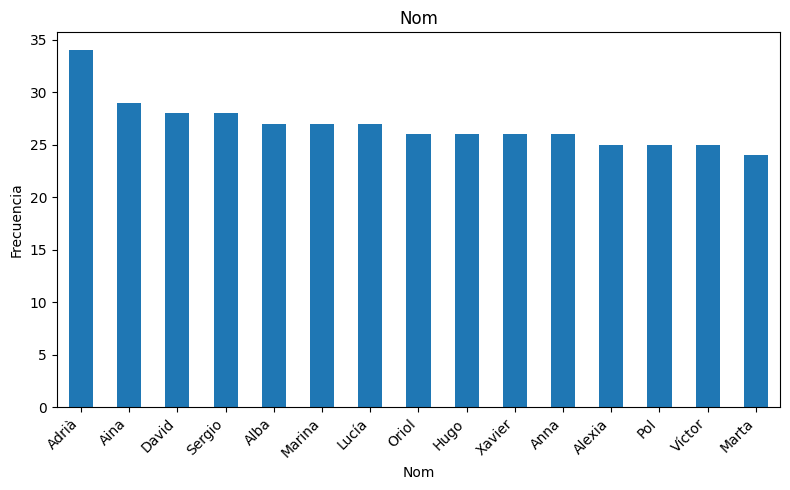

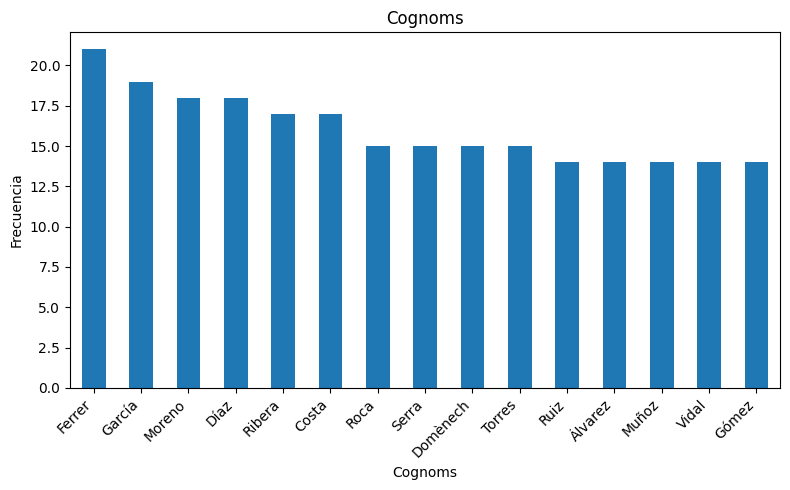

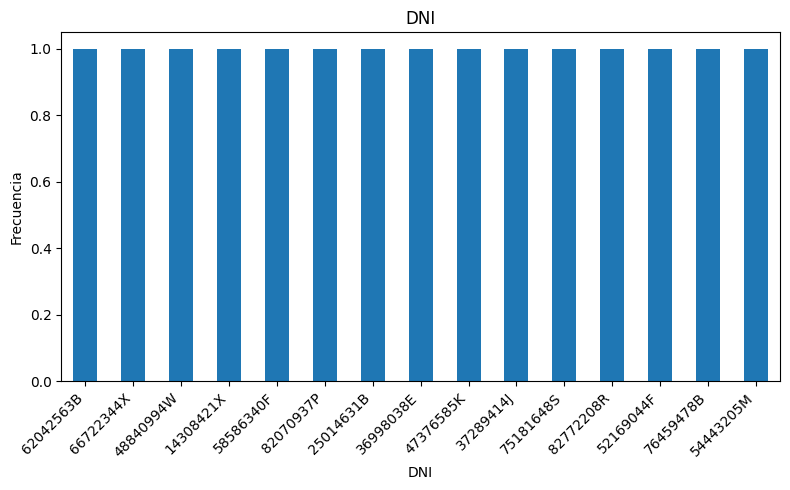

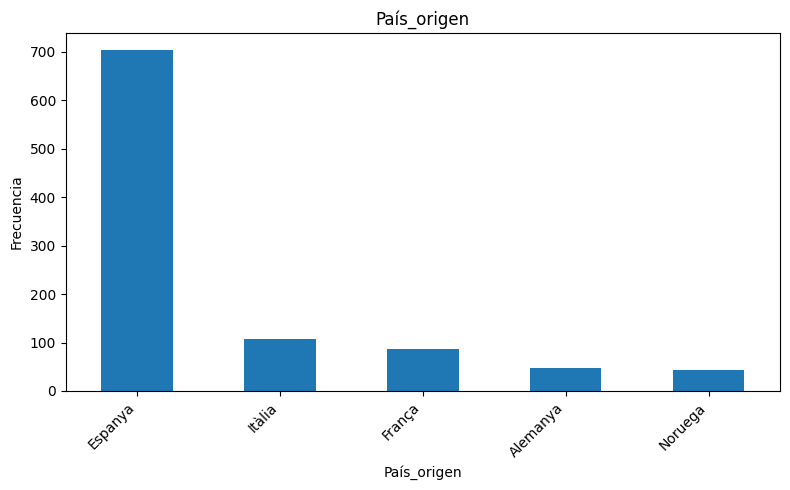

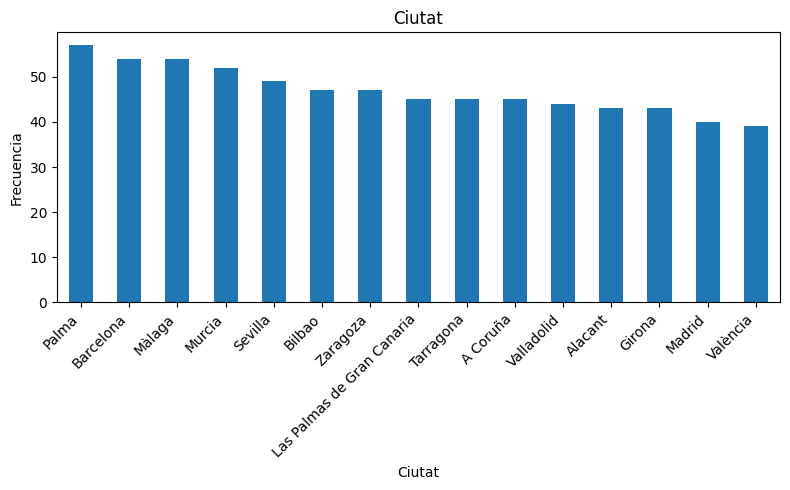

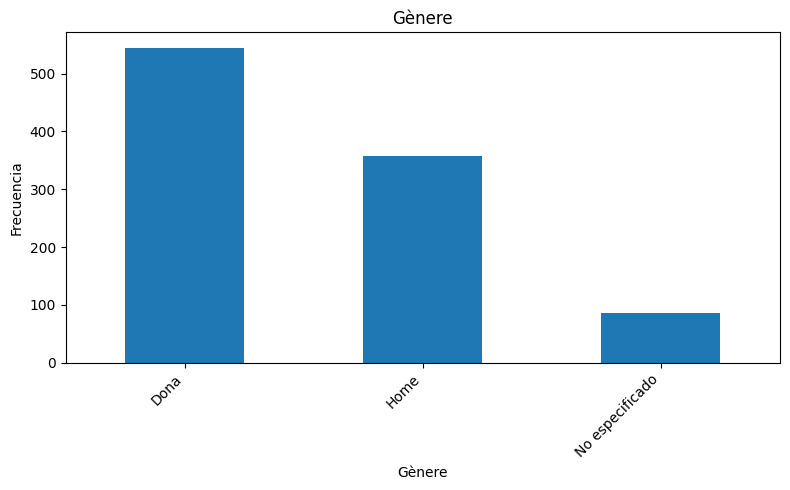

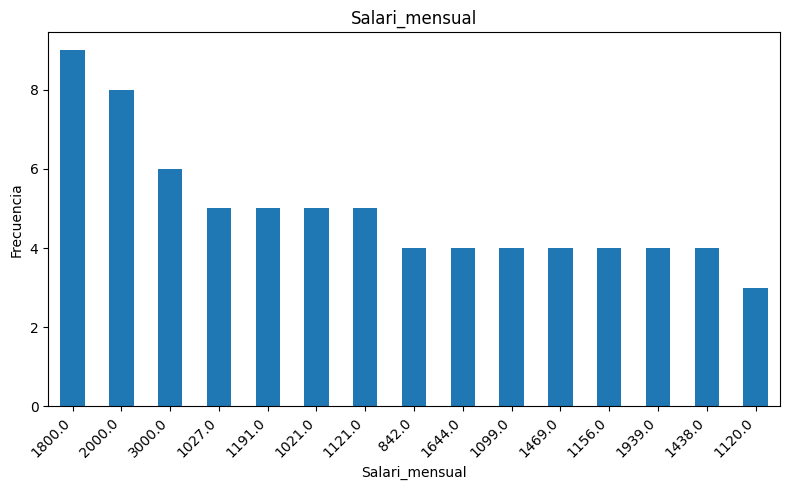

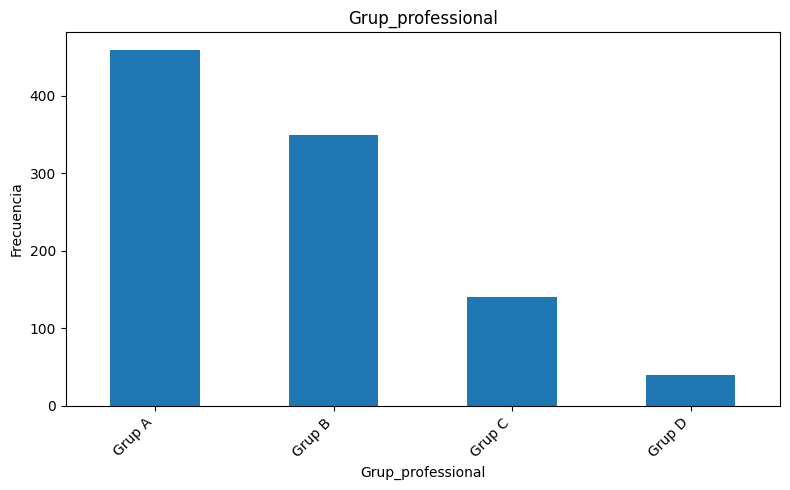

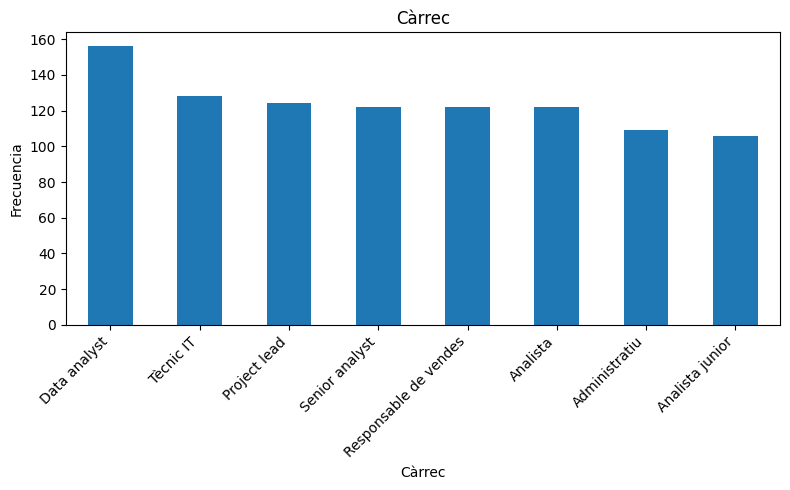

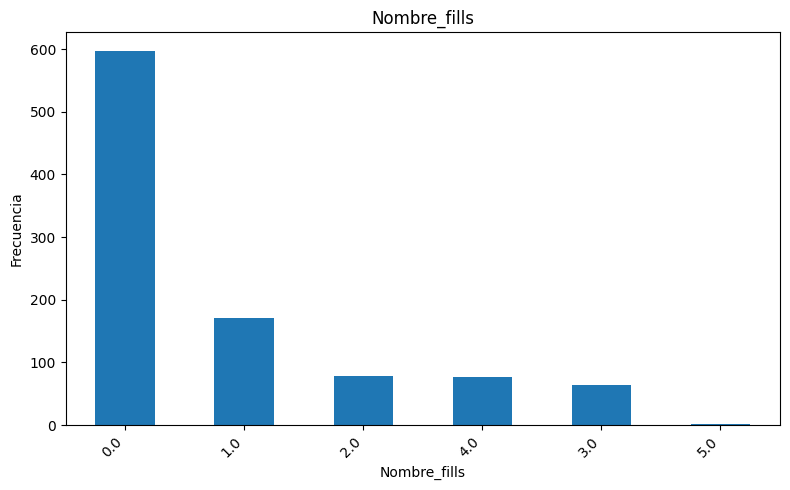

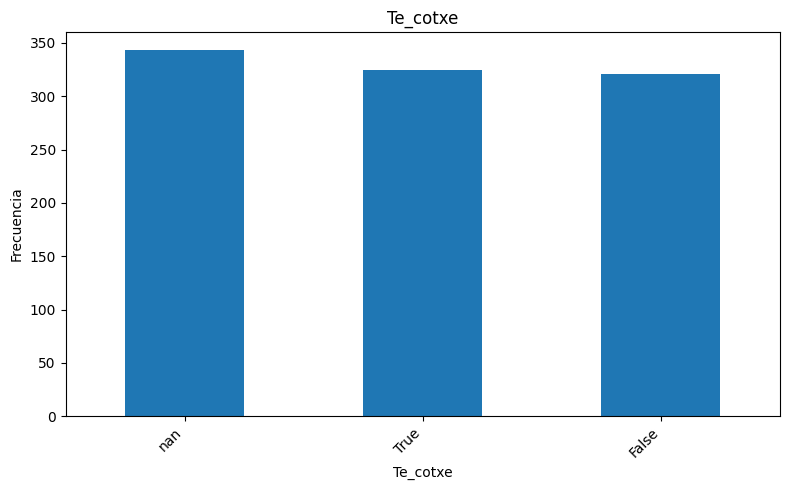

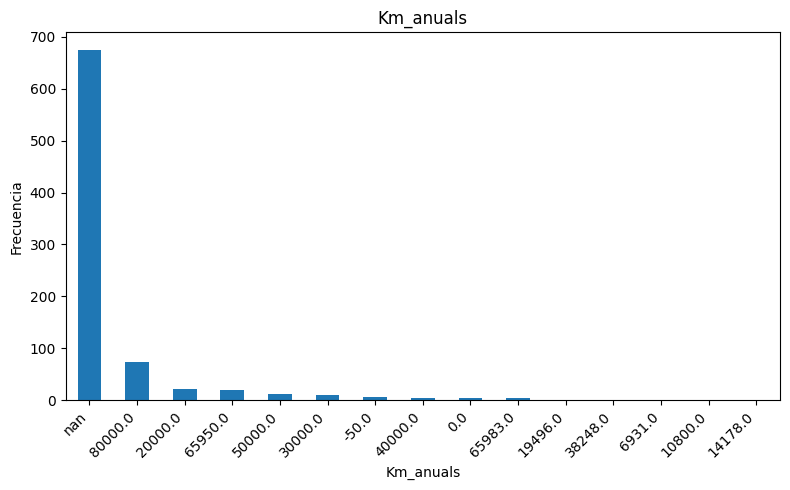

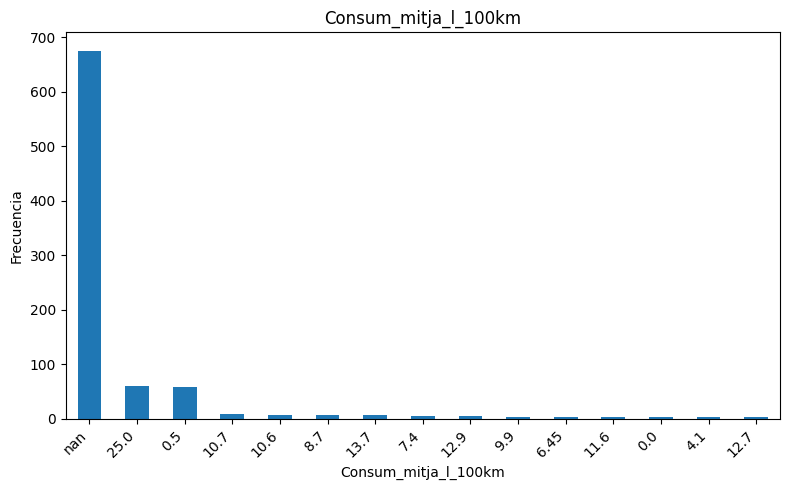

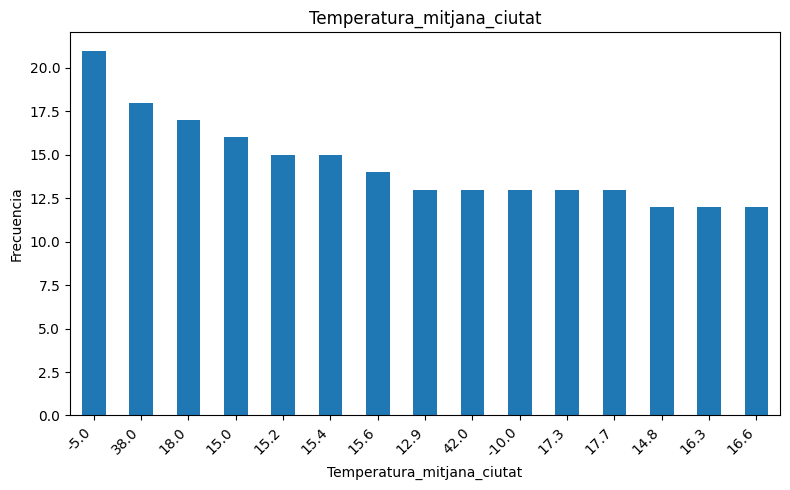

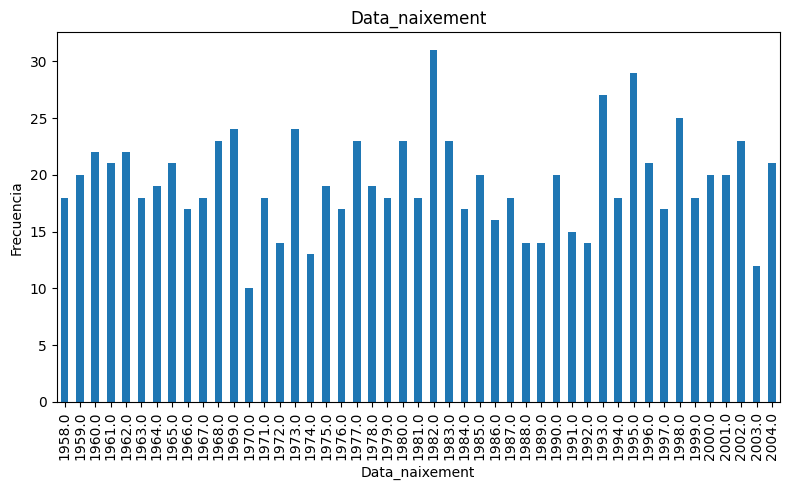

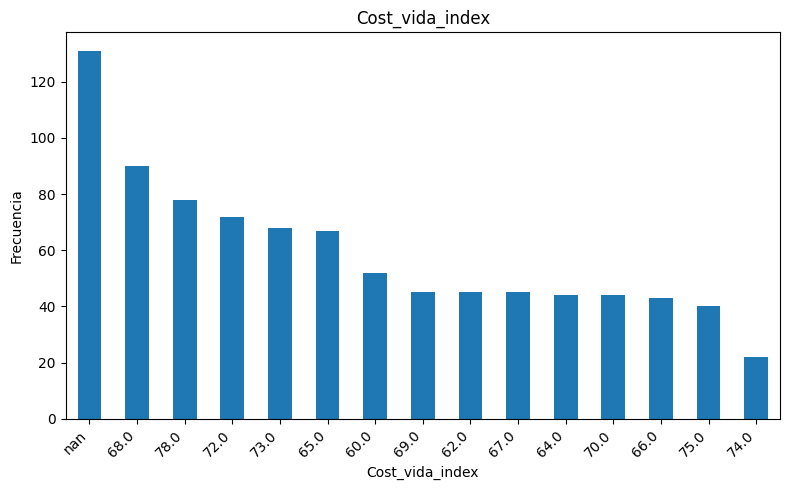

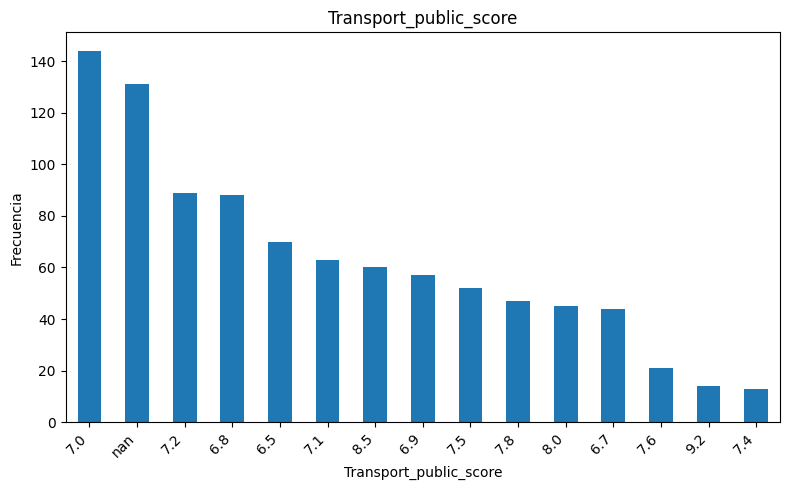

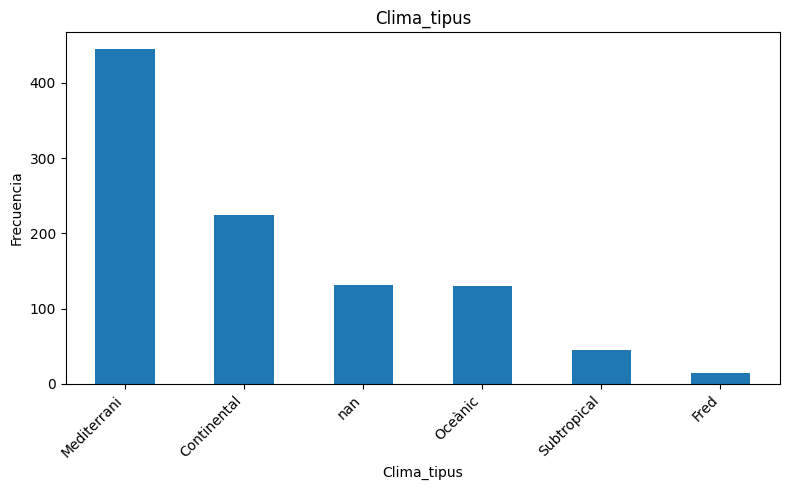

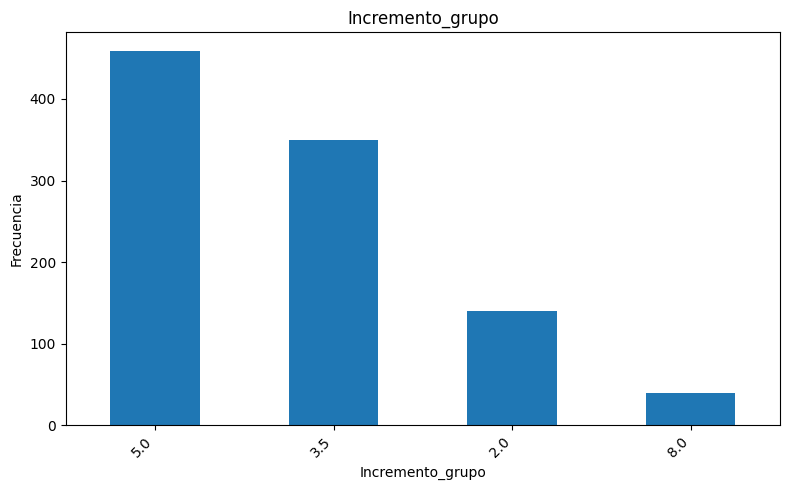

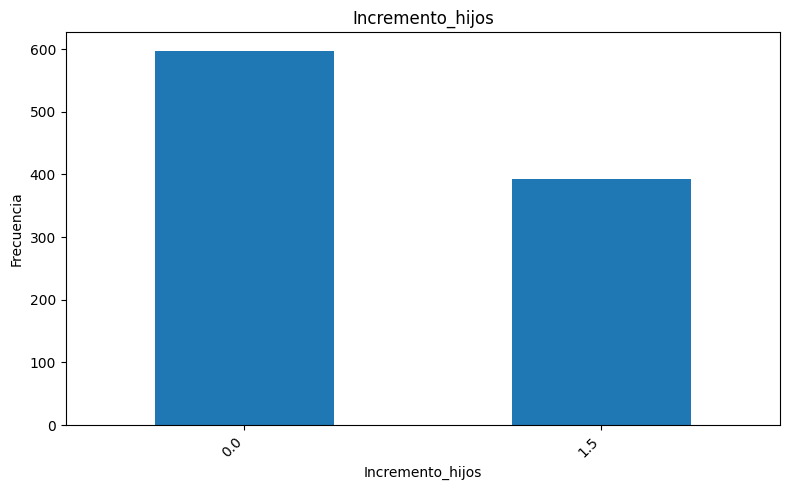

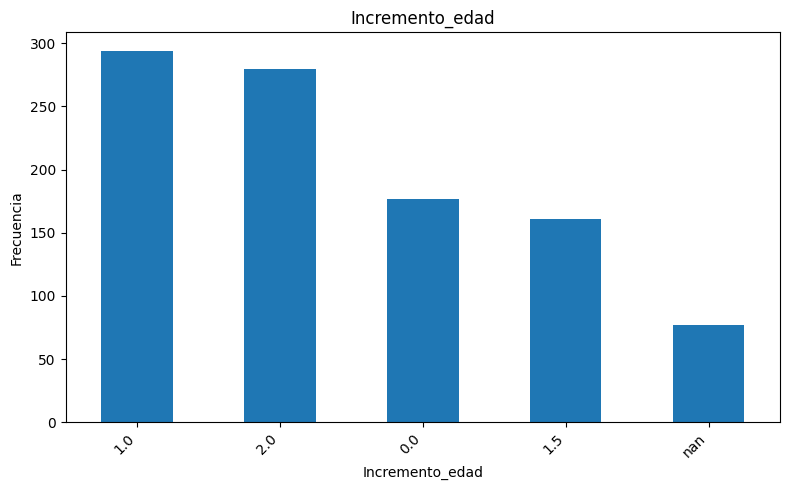

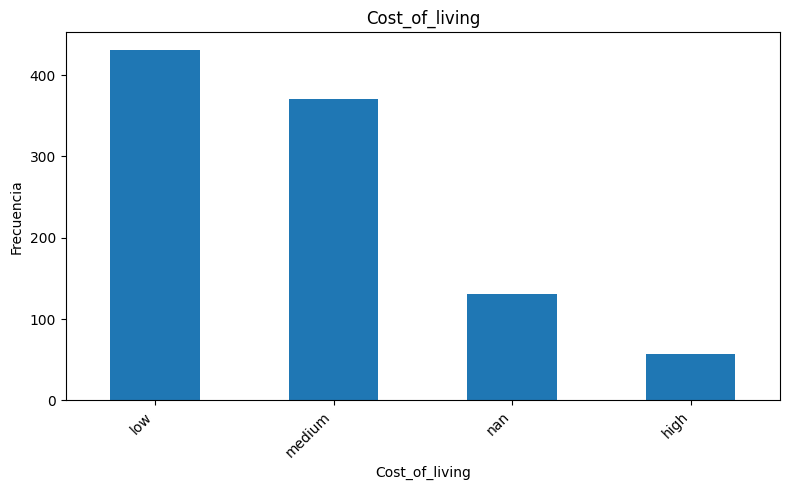

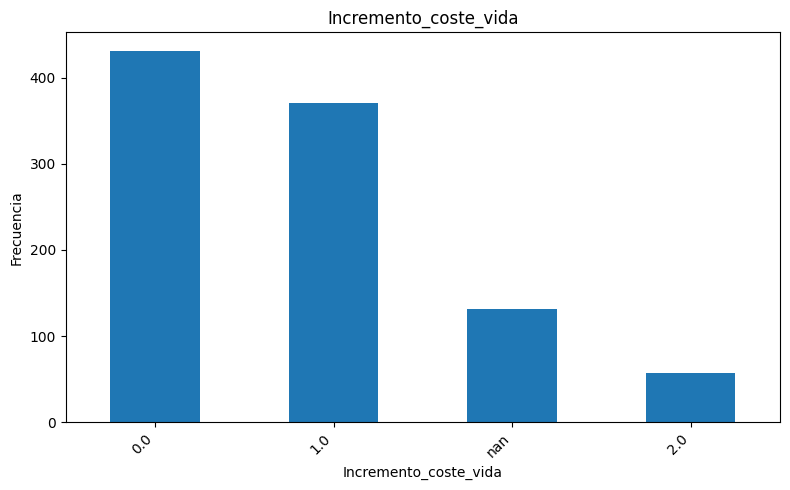

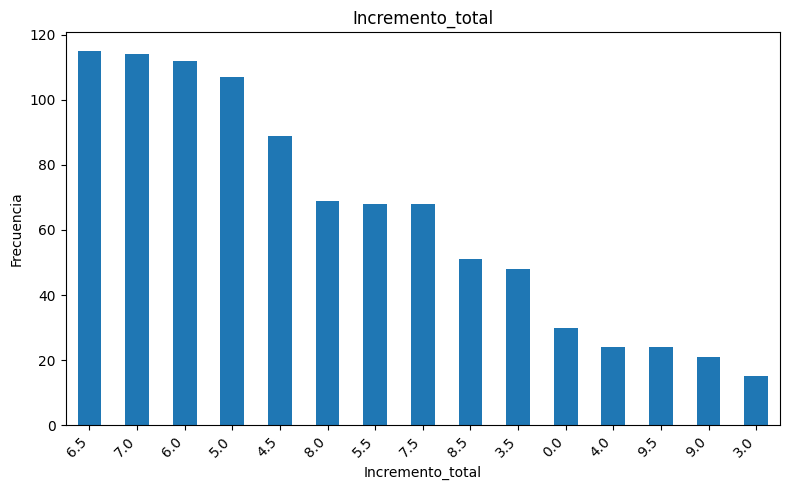

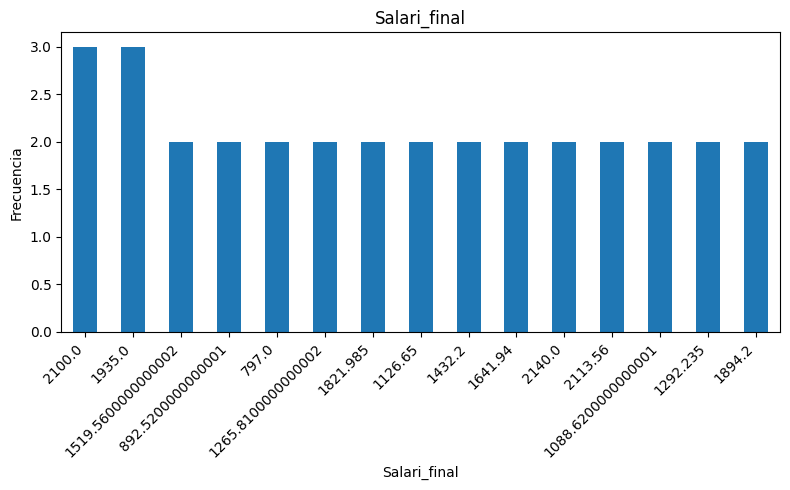

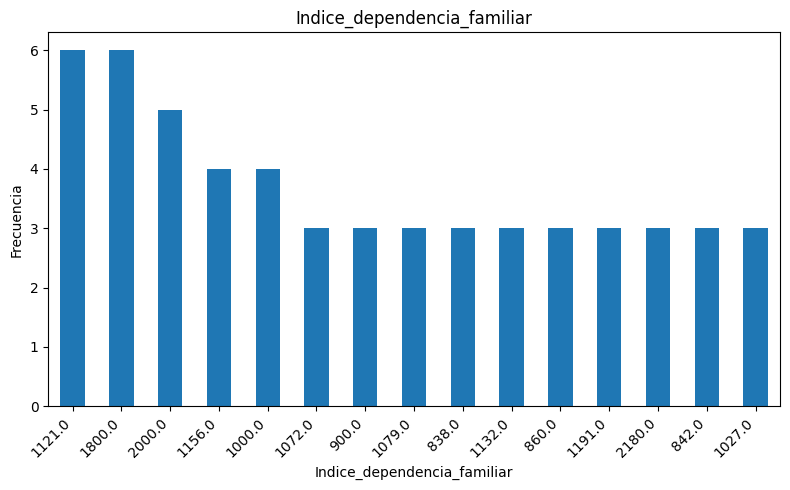

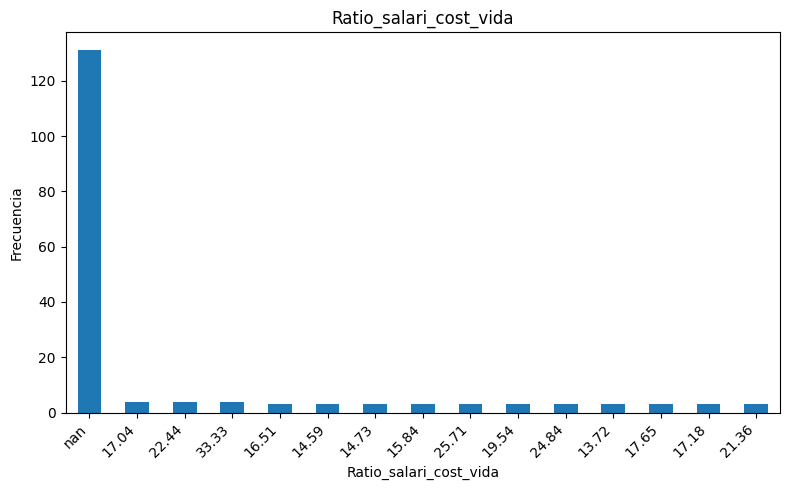

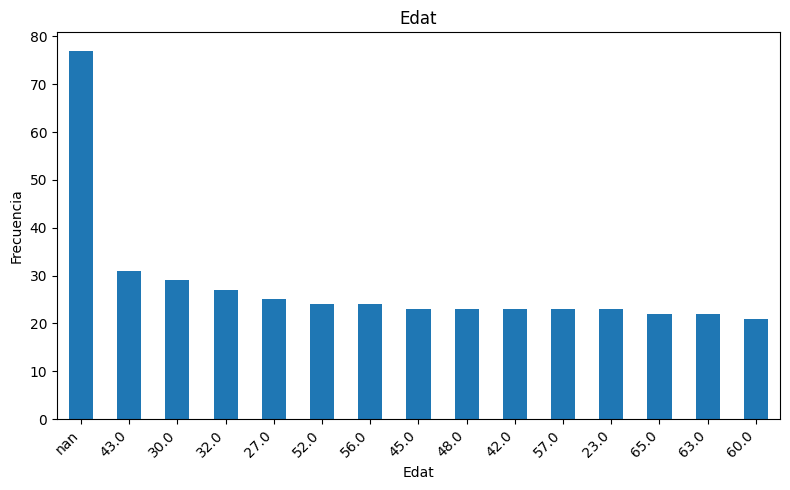

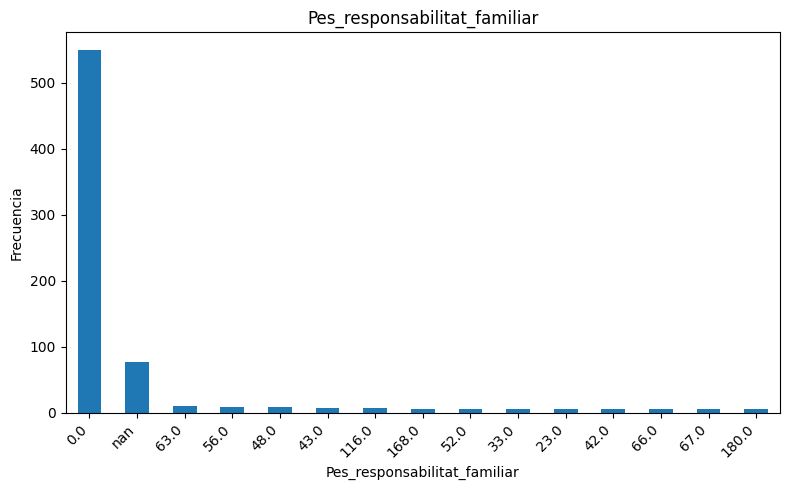

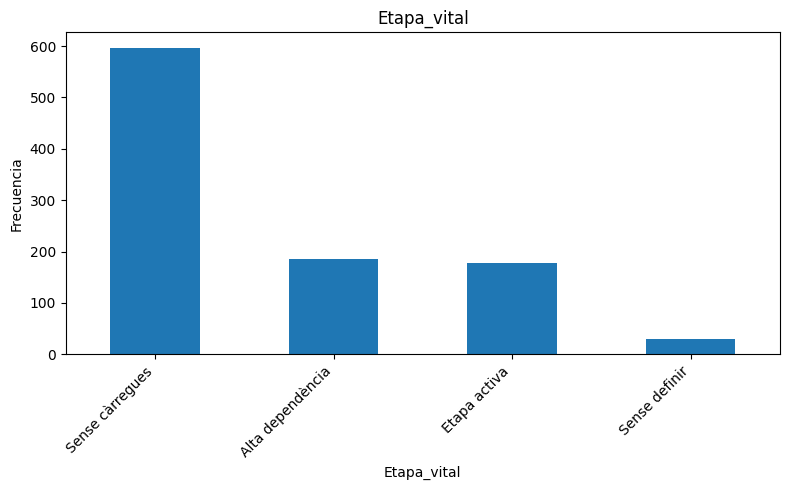

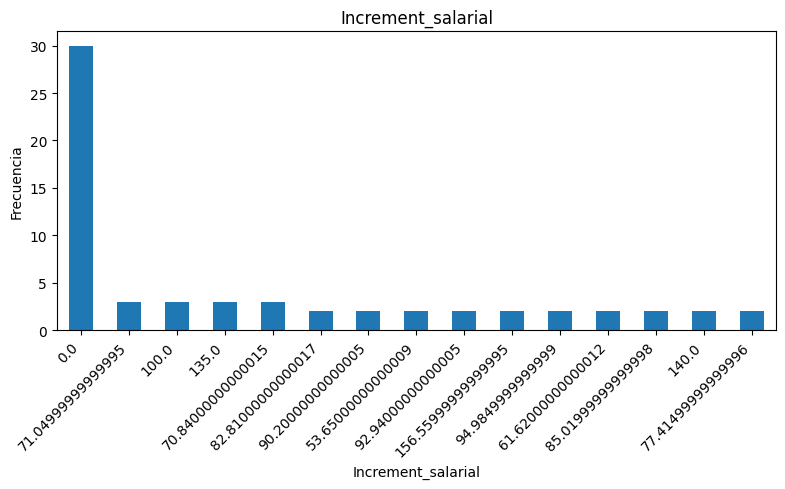

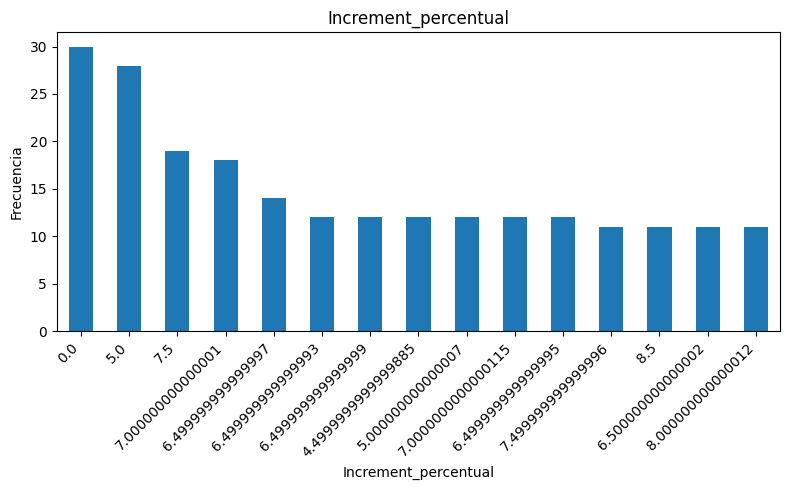

In [189]:
graficar_dataset(df, mostrar=True)

################################################################


# 10. Optimización de rutas
## Contexto de negocio

La empresa quiere comenzar a controlar los desplazamientos de los empleados.

Antes de invertir en sistemas complejos, quiere realizar una prueba piloto.

No necesita la ruta óptima.

Necesita una ruta razonable, sencilla de explicar y suficientemente buena.

## Plan de ejecución


1.   Cargar la matriz de distancias.
2.   Eliminar ciudades fuera del alcance de la prueba.
3.   Recibir origen y destino.
4.   Visitar siempre la ciudad no visitada más cercana.
5.   Finalizar cuando se alcance el destino.
6.   Mostrar:
*   Ruta seguida
*   Distancia total

El algoritmo elegido es el de vecino más cercano (Nearest Neighbour), una heurística muy utilizada para obtener soluciones rápidas cuando no es necesario encontrar el óptimo absoluto.

In [190]:
df_matriu_distancies = pd.read_excel("/content/drive/MyDrive/matriu_distancies.xlsx")
print(df_matriu_distancies.shape)

(15, 16)


In [191]:
df_matriu_distancies = df_matriu_distancies.set_index("Unnamed: 0")
df_matriu_distancies

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Palma,Las Palmas de Gran Canaria,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Unnamed: 0,,,,,,,,,,,,,,,
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,206.0,2175.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,260.0,1874.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,791.0,1355.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,377.0,2001.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,695.0,1406.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,372.0,1723.0,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Palma,206.0,260.0,791.0,377.0,695.0,372.0,NaN,2093.0,621.0,303.0,671.0,664.0,1000.0,820.0,204.0
Las Palmas de Gran Canaria,2175.0,1874.0,1355.0,2001.0,1406.0,1723.0,2093.0,NaN,2022.0,1792.0,1470.0,1790.0,1682.0,1925.0,2168.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,621.0,2022.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0


In [192]:
ciudades_eliminar = ["Palma", "Las Palmas de Gran Canaria"]

df_matriu_distancies = (
    df_matriu_distancies
    .drop(index=ciudades_eliminar, columns=ciudades_eliminar)
)

print(df_matriu_distancies.shape)
df_matriu_distancies

(13, 13)


,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Unnamed: 0,,,,,,,,,,,,,
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0


In [193]:
def calcular_ruta(df, origen, destino):

    # Comprobaciones
    if origen not in df.index:
        raise ValueError(f"{origen} no existe en la matriz.")

    if destino not in df.index:
        raise ValueError(f"{destino} no existe en la matriz.")

    ruta = [origen]

    distancia_total = 0

    ciudad_actual = origen

    visitadas = {origen}

    while ciudad_actual != destino:

        # Distancias desde la ciudad actual
        distancias = df.loc[ciudad_actual]

        # Eliminamos ciudades ya visitadas
        distancias = distancias.drop(labels=visitadas)

        # Ciudad más cercana
        siguiente = distancias.idxmin()

        # Sumamos kilómetros
        distancia_total += distancias.min()

        # Actualizamos variables
        ruta.append(siguiente)

        visitadas.add(siguiente)

        ciudad_actual = siguiente

    return ruta, distancia_total

In [194]:
ruta, km = calcular_ruta(
    df_matriu_distancies,
    origen="Barcelona",
    destino="Bilbao"
)

print("Ruta:\n")
print("\n↓\n".join(ruta))

print(f"\nDistancia total: {km:.1f} km")

Ruta:

Barcelona
↓
Hospitalet de Llobregat
↓
Zaragoza
↓
Valencia
↓
Alicante
↓
Murcia
↓
Córdoba
↓
Sevilla
↓
Málaga
↓
Valladolid
↓
Gijón
↓
Bilbao

Distancia total: 2292.0 km
